## 노트북 정리

- 전체 t 데이터 파일을 한 번에 훑어보고, 어떤 테이블을 분석에 쓸지 정리한 EDA 노트북.
- 테이블별 컬럼, 기간, CNT 규모, 월별 추세, 지역별 차이를 확인해서 데이터 구조를 먼저 파악함.
- population_total.csv를 붙여서 행정동별 인구, 세대수, 세대당 인구와 유동인구를 같이 볼 수 있게 만듦.
- t24를 중심으로 인구 1,000명당 유동 규모, 상위 행정동, 변화율, 시간대/목적 코드 구성을 시각화함.
- 맨 아래에는 젠트리피케이션 예측에 쓸 변수별 해석과 예측 변수 후보 선택 기준을 정리함.


In [58]:
import pandas as pd
import duckdb
import pyarrow.parquet as pq
import matplotlib

try:
    shell = get_ipython()
except NameError:
    shell = None

if shell is not None:
    matplotlib.use("module://matplotlib_inline.backend_inline", force=True)
    shell.run_line_magic("matplotlib", "inline")
else:
    matplotlib.use("Agg", force=True)

import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np
from pathlib import Path

def find_data_dir():
    candidates = [
        Path("../data"),
        Path("data"),
        Path.cwd() / "data",
        Path.cwd().parent / "data",
    ]
    for candidate in candidates:
        if (candidate / "population_total.csv").exists():
            return candidate
    raise FileNotFoundError("data 폴더를 찾지 못했습니다. 노트북을 final_project 또는 Jiryun 폴더에서 실행해 주세요.")

DATA_DIR = find_data_dir()

available_fonts = {font.name for font in font_manager.fontManager.ttflist}
for font_name in ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]:
    if font_name in available_fonts:
        plt.rcParams["font.family"] = font_name
        break
plt.rcParams["axes.unicode_minus"] = False

# 전체 t 데이터를 모두 스캔하는 EDA는 오래 걸릴 수 있으므로 기본값은 False입니다.
# 전체 t 통합 표가 필요할 때만 True로 바꾼 뒤 앞쪽 전체 t EDA 셀들을 실행하세요.
RUN_FULL_T_EDA = True

# 전체 t 데이터 EDA 실행 옵션
# RUN_FULL_T_EDA=True: 상대적으로 가벼운 전체 t 요약/월별/지역/목적/교통/성연령/시간/요일/OD 집계 실행
# RUN_FULL_T_HEAVY_EDA=True: 체류시간, 품질점검처럼 수억 행 파일을 다시 스캔하는 고비용 집계 실행
# RUN_MONTHLY_ADMIN_ALL_T=True: 전체 t 테이블을 월별 행정동 단위로 통합 집계
RUN_FULL_T_EDA = False
RUN_FULL_T_HEAVY_EDA = False
RUN_MONTHLY_ADMIN_ALL_T = False


  | 데이터 | 단위 | 기준 | 주요 의미 |
  |---|---|---|---|
  | t4 | 시군구 | 도착지 + 목적 | 어느 구로, 어떤 목적의 사람이 유입됐는지 |
  | t5 | 행정동 | 도착지 + 목적 | 어느 행정동으로, 어떤 목적의 사람이 유입됐는지 |
  | t6 | 시군구 | 도착지 + 교통수단 | 어느 구로, 어떤 교통수단으로 도착했는지 |
  | t7 | 행정동 | 도착지 + 교통수단 | 어느 행정동으로, 어떤 교통수단으로 도착했는지 |
  | t8 | 시군구 | 출발지 + 목적 | 어느 구에서, 어떤 목적의 이동이 시작됐는지 |
  | t9 | 행정동 | 출발지 + 목적 | 어느 행정동에서, 어떤 목적의 이동이 시작됐는지 |
  | t10 | 시군구 | 출발지 + 교통수단 | 어느 구에서, 어떤 교통수단 이동이 시작됐는지 |
  | t11 | 행정동 | 출발지 + 교통수단 | 어느 행정동에서, 어떤 교통수단 이동이 시작됐는지 |
  | t12 | 시군구 OD | 출발지→도착지 + 목적 | 구 간 이동을 목적별로 본 데이터 |
  | t13 | 행정동 OD | 출발지→도착지 + 목적 | 행정동 간 이동을 목적별로 본 데이터 |
  | t14 | 시군구 OD | 출발지→도착지 + 교통수단 | 구 간 이동을 교통수단별로 본 데이터 |
  | t16 | 시군구 | 도착지 + 목적 + 체류시간 | 어느 구에 도착해 얼마나 머무는지 |
  | t22 | 행정동 | 시간대 + 성별/연령 + 내외국인 | 행정동별 시간대 생활/체류 인구 성격 |
  | t23 | 시군구 | 시간대 + 목적 | 구 단위 시간대별 목적 유동인구 |
  | t24 | 행정동 | 시간대 + 목적 | 행정동 단위 시간대별 목적 유동인구 |
  | t25 | 시군구 OD | 출발지→도착지 + 시간대 + 목적 + 교통수단 | 구 간 이동을 시간·목적·교통수단까지 세분화 |
  | t26 | 행정동 | 도착지 + 시간대 + 목적 + 교통수단 + 체류시간 | 행정동별 도착/체류 특성 |
  | t27 | 행정동 | 출발지 + 시간대 + 목적 + 교통수단 + 체류시간 | 행정동별 출발/이탈 특성 |

# 전체 t 데이터 EDA

아래 섹션은 `data` 폴더에 있는 t 데이터 전체를 대상으로 합니다. 같은 테이블의 중복 버전(`_all`, `_final`, `_final_v2`, `_date_final`)을 모두 더하면 동일 데이터가 중복 집계되므로, 각 `t번호`별 최종본 1개씩만 사용합니다.

사용 대상은 `t4, t5, t6, t7, t8, t9, t10, t11, t12, t13, t14, t16, t22, t23, t24, t25, t26, t27`입니다. 원본 행을 일부 샘플링하지 않고 전체 parquet를 DuckDB로 스캔한 뒤, 그래프에 필요한 집계 결과만 pandas 데이터프레임으로 가져옵니다.

## 실행 옵션

`RUN_FULL_T_EDA=True`는 전체 t 데이터를 요약하는 비교적 가벼운 집계만 실행합니다. `RUN_FULL_T_HEAVY_EDA=True`나 `RUN_MONTHLY_ADMIN_ALL_T=True`는 수억 행 파일을 추가로 스캔하므로 시간이 오래 걸립니다. 팀 기준인 월별 행정동 분석은 아래의 빠른 `t24_monthly_admin_panel`만으로 바로 진행할 수 있습니다.


In [59]:
from pathlib import Path
import pyarrow.parquet as parquet

T_DATA_FILES = {
    "t4": "t4_2023_2025_all_date_final.parquet",
    "t5": "t5_2023_2025_all_date_final.parquet",
    "t6": "t6_2023_2025_all_date_final.parquet",
    "t7": "t7_2023_2025_all_date_final.parquet",
    "t8": "t8_2023_2025_all_date_final.parquet",
    "t9": "t9_2023_2025_all_date_final.parquet",
    "t10": "t10_2023_2025_all_date_final.parquet",
    "t11": "t11_2023_2025_all_date_final.parquet",
    "t12": "t12_2023_2025_all_final_v2.parquet",
    "t13": "t13_2023_2025_all_final_v2.parquet",
    "t14": "t14_2023_2025_all_final_v2.parquet",
    "t16": "t16_2023_2025_all_date_final.parquet",
    "t22": "t22_2023_2025_all_date_final.parquet",
    "t23": "t23_2023_2025_all_date_final.parquet",
    "t24": "t24_2023_2025_all_date_final.parquet",
    "t25": "t25_2023_2025_all_final_v2.parquet",
    "t26": "t26_2023_2025_all_final.parquet",
    "t27": "t27_2023_2025_all_final.parquet",
}

T_DATA_DESC = {
    "t4": "도착 시군구-목적-성별-연령-월/요일",
    "t5": "도착 행정동-목적-성별-연령-일자",
    "t6": "도착 시군구-교통수단-성별-연령-월/요일",
    "t7": "도착 행정동-교통수단-성별-연령-일자",
    "t8": "출발 시군구-목적-성별-연령-월/요일",
    "t9": "출발 행정동-목적-성별-연령-일자",
    "t10": "출발 시군구-교통수단-성별-연령-월/요일",
    "t11": "출발 행정동-교통수단-성별-연령-일자",
    "t12": "시군구 OD-목적-성별-연령-월/요일",
    "t13": "행정동 OD-목적-성별-연령-일자",
    "t14": "시군구 OD-교통수단-성별-연령-월/요일",
    "t16": "도착 시군구-체류시간-목적-성별-연령-월/요일",
    "t22": "행정동 시간대별 성별·연령 생활/체류 인구",
    "t23": "시군구 시간대별 목적 유동인구",
    "t24": "행정동 시간대별 목적 유동인구",
    "t25": "시군구 OD-시간대-목적-교통수단-성별-연령",
    "t26": "도착 행정동-시간대-목적-교통수단-체류시간",
    "t27": "출발 행정동-시간대-목적-교통수단-체류시간",
}

def parquet_path(table_id):
    return (DATA_DIR / T_DATA_FILES[table_id]).as_posix()

metadata_rows = []
schema_rows = []

for table_id, file_name in T_DATA_FILES.items():
    file_path = DATA_DIR / file_name
    pf = parquet.ParquetFile(file_path)
    columns = pf.schema_arrow.names
    metadata_rows.append({
        "TABLE_ID": table_id,
        "DESCRIPTION": T_DATA_DESC[table_id],
        "FILE_NAME": file_name,
        "ROWS": pf.metadata.num_rows,
        "COLS": len(columns),
        "ROW_GROUPS": pf.metadata.num_row_groups,
        "SIZE_MB": round(file_path.stat().st_size / 1024 / 1024, 1),
    })
    for order, column in enumerate(columns, start=1):
        schema_rows.append({
            "TABLE_ID": table_id,
            "COLUMN_ORDER": order,
            "COLUMN": column,
        })

t_file_inventory = pd.DataFrame(metadata_rows)
t_schema_inventory = pd.DataFrame(schema_rows)
t_schema_map = t_schema_inventory.groupby("TABLE_ID")["COLUMN"].apply(list).to_dict()

t_file_inventory


,TABLE_ID,DESCRIPTION,FILE_NAME,ROWS,COLS,ROW_GROUPS,SIZE_MB
0,t4,도착 시군구-목적-성별-연령-월/요일,t4_2023_2025_all_date_final.parquet,1211106,12,2,8.4
1,t5,도착 행정동-목적-성별-연령-일자,t5_2023_2025_all_date_final.parquet,43306619,12,42,253.3
2,t6,도착 시군구-교통수단-성별-연령-월/요일,t6_2023_2025_all_date_final.parquet,1927203,12,2,12.6
3,t7,도착 행정동-교통수단-성별-연령-일자,t7_2023_2025_all_date_final.parquet,68932750,12,66,386.0
4,t8,출발 시군구-목적-성별-연령-월/요일,t8_2023_2025_all_date_final.parquet,1638511,12,2,10.6
5,t9,출발 행정동-목적-성별-연령-일자,t9_2023_2025_all_date_final.parquet,50298816,12,48,289.4
6,t10,출발 시군구-교통수단-성별-연령-월/요일,t10_2023_2025_all_date_final.parquet,1971599,12,2,12.9
7,t11,출발 행정동-교통수단-성별-연령-일자,t11_2023_2025_all_date_final.parquet,71457282,12,69,403.4
8,t12,시군구 OD-목적-성별-연령-월/요일,t12_2023_2025_all_final_v2.parquet,6743756,16,7,42.9
9,t13,행정동 OD-목적-성별-연령-일자,t13_2023_2025_all_final_v2.parquet,279996851,17,2251,3538.0


**데이터프레임 설명 - `t_file_inventory`**

전체 EDA에 사용하는 최종 t 테이블 목록입니다. `ROWS`는 실제 parquet 메타데이터 기준 전체 행 수이고, `SIZE_MB`는 파일 크기입니다. 여기서 보이는 모든 테이블이 이후 EDA에 사용됩니다.

핵심 설명: 이 표는 이후 그래프를 해석하기 위한 기준 데이터입니다. 행 수, 기간, 지역 단위, 비중·변화율 컬럼을 먼저 확인하고 그래프를 읽으면 됩니다.


In [60]:
t_schema_inventory


,TABLE_ID,COLUMN_ORDER,COLUMN
0,t4,1,ETL_YM
1,t4,2,DOW
2,t4,3,D_TIME_CD
3,t4,4,D_CTY_CD
4,t4,5,D_MEGA_NM
...,...,...,...
253,t27,11,PURPOSE
254,t27,12,TRANS_GB
255,t27,13,DURATION
256,t27,14,SEX_CD


**데이터프레임 설명 - `t_schema_inventory`**

각 t 테이블이 가진 컬럼 목록입니다. `O_`로 시작하면 출발지(origin), `D_`로 시작하면 도착지(destination), 접두사가 없는 `CTY_NM`, `ADMI_NM`은 단일 지역 기준 컬럼으로 해석합니다.

핵심 설명: 이 표는 이후 그래프를 해석하기 위한 기준 데이터입니다. 행 수, 기간, 지역 단위, 비중·변화율 컬럼을 먼저 확인하고 그래프를 읽으면 됩니다.


In [61]:
con = duckdb.connect()
con.execute("PRAGMA threads=4")

def scan_sql(table_id):
    return f"read_parquet('{parquet_path(table_id)}')"

def q(sql):
    return con.execute(sql).df()

def qname(column):
    return '"' + column.replace('"', '""') + '"'

def table_columns(table_id):
    return t_schema_map[table_id]

def cnt_expr(table_id):
    cols = table_columns(table_id)
    if "CNT" in cols:
        return "CNT"
    cnt_cols = [col for col in cols if col.endswith("_CNT")]
    return " + ".join([f"COALESCE({qname(col)}, 0)" for col in cnt_cols])

def parse_date_sql(column):
    col = qname(column)
    value = f"CAST({col} AS VARCHAR)"
    return (
        f"COALESCE("
        f"TRY_CAST({value} AS DATE), "
        f"CAST(try_strptime({value}, '%Y%m%d') AS DATE), "
        f"CAST(try_strptime({value}, '%Y%m') AS DATE), "
        f"CAST(try_strptime({value}, '%Y-%m-%d') AS DATE)"
        f")"
    )

def date_expr(table_id):
    cols = table_columns(table_id)
    if "ETL_YMD" in cols:
        return parse_date_sql("ETL_YMD")
    if "ETL_YM" in cols:
        return parse_date_sql("ETL_YM")
    return None

def union_query(parts):
    return "\nUNION ALL\n".join(parts)


**설명 - 전체 parquet 스캔 함수**

`scan_sql()`은 parquet 파일을 DuckDB가 직접 읽도록 하고, `cnt_expr()`은 대부분의 테이블의 `CNT`와 `t22`처럼 성별·연령별 count 컬럼이 넓게 펼쳐진 구조를 같은 총량 기준으로 맞춥니다. 이 방식은 원본 전체 행을 사용하지만, 집계 결과만 메모리에 올립니다.


In [62]:
if RUN_FULL_T_EDA:
    overview_parts = []
    for table_id in T_DATA_FILES:
        date_col = date_expr(table_id)
        start_date_sql = f"MIN({date_col})" if date_col else "NULL"
        end_date_sql = f"MAX({date_col})" if date_col else "NULL"
        overview_parts.append(f'''
            SELECT
                '{table_id}' AS TABLE_ID,
                '{T_DATA_DESC[table_id]}' AS DESCRIPTION,
                COUNT(*) AS ROWS_SCANNED,
                SUM({cnt_expr(table_id)}) AS CNT_SUM,
                AVG({cnt_expr(table_id)}) AS CNT_MEAN,
                {start_date_sql} AS START_DATE,
                {end_date_sql} AS END_DATE
            FROM {scan_sql(table_id)}
        ''')

    all_t_overview = q(union_query(overview_parts)).merge(t_file_inventory, on=["TABLE_ID", "DESCRIPTION"], how="left")
    all_t_overview = all_t_overview[[
        "TABLE_ID", "DESCRIPTION", "FILE_NAME", "ROWS", "ROWS_SCANNED", "COLS",
        "SIZE_MB", "CNT_SUM", "CNT_MEAN", "START_DATE", "END_DATE"
    ]]
    all_t_overview
else:
    all_t_overview = pd.DataFrame()
    pd.DataFrame({"안내": ["전체 t 테이블 요약는 대용량 전체 t 스캔이라 기본 실행을 건너뜁니다.", "필요하면 첫 셀에서 RUN_FULL_T_EDA = True로 바꾸고 다시 실행하세요."]})


**데이터프레임 설명 - `all_t_overview`**

모든 t 최종본을 실제로 스캔해서 만든 전체 요약입니다. `ROWS`와 `ROWS_SCANNED`가 같으면 파일 메타데이터와 DuckDB 스캔 결과가 일치한다는 뜻입니다. `CNT_SUM`은 테이블별 총 유동/생활 인구 규모를 비교하는 기준입니다.

핵심 설명: 이 표는 이후 그래프를 해석하기 위한 기준 데이터입니다. 행 수, 기간, 지역 단위, 비중·변화율 컬럼을 먼저 확인하고 그래프를 읽으면 됩니다.


In [63]:
if "all_t_overview" not in globals() or (hasattr(all_t_overview, "empty") and all_t_overview.empty):
    pd.DataFrame({"안내": ["전체 t 테이블별 CNT 총합 그래프는 대용량 셀을 건너뛰어서 실행하지 않습니다.", "월별 행정동 분석은 아래 빠른 t24 패널과 시각화 섹션을 사용하세요."]})
else:
    ax = all_t_overview.sort_values("CNT_SUM").plot(
        kind="barh",
        x="TABLE_ID",
        y="CNT_SUM",
        figsize=(10, 8),
        legend=False,
        title="전체 t 테이블별 CNT 총합",
    )
    ax.set_xlabel("CNT 총합")
    ax.set_ylabel("테이블")
    plt.tight_layout()
    plt.show()


**그래프 설명 - 전체 t 테이블별 CNT 총합**

각 t 테이블을 전체 행 기준으로 집계한 총량 비교입니다. 단, 테이블마다 분석 단위가 다르므로 절대 총량이 큰 테이블이 더 중요하다는 의미는 아닙니다. 어느 데이터가 전체 분석에서 규모가 큰지, 이후 세부 EDA 우선순위를 정하는 용도로 봅니다.


In [64]:
if RUN_FULL_T_EDA:
    monthly_parts = []
    for table_id in T_DATA_FILES:
        d = date_expr(table_id)
        if d is None:
            continue
        monthly_parts.append(f'''
            SELECT
                '{table_id}' AS TABLE_ID,
                CAST(date_trunc('month', {d}) AS DATE) AS MONTH_START,
                SUM({cnt_expr(table_id)}) AS CNT_SUM
            FROM {scan_sql(table_id)}
            GROUP BY 1, 2
        ''')

    all_t_monthly = q(union_query(monthly_parts)).sort_values(["TABLE_ID", "MONTH_START"])
    all_t_monthly["YEAR_MONTH"] = pd.to_datetime(all_t_monthly["MONTH_START"]).dt.strftime("%Y-%m")
    all_t_monthly
else:
    all_t_monthly = pd.DataFrame()
    pd.DataFrame({"안내": ["전체 t 월별 추세는 대용량 전체 t 스캔이라 기본 실행을 건너뜁니다.", "필요하면 첫 셀에서 RUN_FULL_T_EDA = True로 바꾸고 다시 실행하세요."]})


**데이터프레임 설명 - `all_t_monthly`**

모든 t 테이블을 월 단위로 맞춘 추세 데이터입니다. 일자 데이터(`ETL_YMD`)와 월 데이터(`ETL_YM`)가 섞여 있으므로, 공통 비교를 위해 모두 월 시작일(`MONTH_START`)로 변환했습니다.

핵심 설명: 이 표는 이후 그래프를 해석하기 위한 기준 데이터입니다. 행 수, 기간, 지역 단위, 비중·변화율 컬럼을 먼저 확인하고 그래프를 읽으면 됩니다.


In [65]:
if "all_t_monthly" not in globals() or (hasattr(all_t_monthly, "empty") and all_t_monthly.empty):
    pd.DataFrame({"안내": ["전체 t 월별 CNT 추세 그래프는 대용량 셀을 건너뛰어서 실행하지 않습니다.", "월별 행정동 분석은 아래 빠른 t24 패널과 시각화 섹션을 사용하세요."]})
else:
    monthly_pivot = all_t_monthly.pivot(index="YEAR_MONTH", columns="TABLE_ID", values="CNT_SUM")
    ax = monthly_pivot.plot(figsize=(16, 6), marker="o", title="전체 t 데이터 월별 CNT 추세")
    ax.set_xlabel("연-월")
    ax.set_ylabel("CNT 총합")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


**그래프 설명 - 전체 t 데이터 월별 CNT 추세**

각 t 테이블의 월별 총량 흐름입니다. 테이블별 스케일 차이가 커서 큰 테이블 위주로 보일 수 있습니다. 특정 월에 여러 테이블이 동시에 변하면 실제 유동 변화 가능성이 크고, 한 테이블만 튀면 해당 테이블의 정의나 수집 특성을 따로 확인해야 합니다.


In [66]:
if "monthly_pivot" not in globals() or (hasattr(monthly_pivot, "empty") and monthly_pivot.empty):
    pd.DataFrame({"안내": ["월별 지수 추세 그래프는 대용량 셀을 건너뛰어서 실행하지 않습니다.", "월별 행정동 분석은 아래 빠른 t24 패널과 시각화 섹션을 사용하세요."]})
else:
    monthly_index = monthly_pivot.divide(monthly_pivot.iloc[0]).multiply(100)
    ax = monthly_index.plot(figsize=(16, 6), marker="o", title="전체 t 데이터 월별 지수 추세 - 첫 월=100")
    ax.set_xlabel("연-월")
    ax.set_ylabel("지수")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


**그래프 설명 - 월별 지수 추세**

각 테이블의 첫 월을 100으로 맞춘 변화율 관점 그래프입니다. 절대 규모가 다른 테이블을 같은 축에서 비교하기 위해 사용합니다. 선이 100보다 높아지면 첫 월 대비 증가, 낮아지면 감소입니다.


In [67]:
if RUN_FULL_T_EDA:
    region_columns = ["CTY_NM", "ADMI_NM", "D_CTY_NM", "D_ADMI_NM", "O_CTY_NM", "O_ADMI_NM"]
    region_parts = []

    for table_id in T_DATA_FILES:
        cols = table_columns(table_id)
        for col in region_columns:
            if col in cols:
                if col.startswith("O_"):
                    role = "출발"
                elif col.startswith("D_"):
                    role = "도착"
                else:
                    role = "단일지역"
                level = "행정동" if "ADMI" in col else "시군구"
                region_parts.append(f'''
                    SELECT
                        '{table_id}' AS TABLE_ID,
                        '{role}' AS REGION_ROLE,
                        '{level}' AS REGION_LEVEL,
                        {qname(col)} AS REGION_NAME,
                        SUM({cnt_expr(table_id)}) AS CNT_SUM
                    FROM {scan_sql(table_id)}
                    WHERE {qname(col)} IS NOT NULL
                    GROUP BY 1, 2, 3, 4
                ''')

    all_t_region = q(union_query(region_parts)).sort_values("CNT_SUM", ascending=False)
    all_t_region.head(30)
else:
    all_t_region = pd.DataFrame()
    pd.DataFrame({"안내": ["전체 t 지역별 집계는 대용량 전체 t 스캔이라 기본 실행을 건너뜁니다.", "필요하면 첫 셀에서 RUN_FULL_T_EDA = True로 바꾸고 다시 실행하세요."]})


**데이터프레임 설명 - `all_t_region`**

모든 t 테이블에서 지역명 컬럼을 찾아 출발/도착/단일지역 기준으로 길게 합친 지역별 집계입니다. `REGION_ROLE`은 출발지인지 도착지인지, `REGION_LEVEL`은 시군구인지 행정동인지를 나타냅니다.

핵심 설명: 이 표는 이후 그래프를 해석하기 위한 기준 데이터입니다. 행 수, 기간, 지역 단위, 비중·변화율 컬럼을 먼저 확인하고 그래프를 읽으면 됩니다.


In [68]:
if "all_t_region" not in globals() or (hasattr(all_t_region, "empty") and all_t_region.empty):
    pd.DataFrame({"안내": ["전체 지역 TOP 30 그래프는 대용량 셀을 건너뛰어서 실행하지 않습니다.", "월별 행정동 분석은 아래 빠른 t24 패널과 시각화 섹션을 사용하세요."]})
else:
    region_top30 = all_t_region.head(30).copy()
    region_top30["LABEL"] = region_top30["TABLE_ID"] + " | " + region_top30["REGION_ROLE"] + " | " + region_top30["REGION_NAME"]

    ax = region_top30.sort_values("CNT_SUM").plot(
        kind="barh",
        x="LABEL",
        y="CNT_SUM",
        figsize=(12, 10),
        legend=False,
        title="전체 t 데이터 지역별 CNT TOP 30",
    )
    ax.set_xlabel("CNT 총합")
    ax.set_ylabel("테이블 | 지역역할 | 지역명")
    plt.tight_layout()
    plt.show()


**그래프 설명 - 전체 지역 TOP 30**

전체 t 데이터에서 CNT 총합이 큰 지역 조합을 보여줍니다. 행정동 단위 테이블은 행 수와 세분화 정도가 다르므로, 같은 지역이라도 `TABLE_ID`와 `REGION_ROLE`을 함께 봐야 합니다.


In [69]:
if RUN_FULL_T_EDA:
    purpose_parts = []
    for table_id in T_DATA_FILES:
        if "PURPOSE" not in table_columns(table_id):
            continue
        purpose_parts.append(f'''
            SELECT
                '{table_id}' AS TABLE_ID,
                PURPOSE,
                SUM({cnt_expr(table_id)}) AS CNT_SUM
            FROM {scan_sql(table_id)}
            GROUP BY 1, 2
        ''')

    all_t_purpose = q(union_query(purpose_parts)).sort_values(["TABLE_ID", "CNT_SUM"], ascending=[True, False])
    all_t_purpose["CNT_SHARE_IN_TABLE"] = all_t_purpose["CNT_SUM"] / all_t_purpose.groupby("TABLE_ID")["CNT_SUM"].transform("sum")
    all_t_purpose
else:
    all_t_purpose = pd.DataFrame()
    pd.DataFrame({"안내": ["전체 t 목적별 집계는 대용량 전체 t 스캔이라 기본 실행을 건너뜁니다.", "필요하면 첫 셀에서 RUN_FULL_T_EDA = True로 바꾸고 다시 실행하세요."]})


**데이터프레임 설명 - `all_t_purpose`**

목적 코드(`PURPOSE`)가 있는 모든 t 테이블의 목적별 총량과 테이블 내부 비중입니다. `CNT_SHARE_IN_TABLE`을 보면 테이블 규모 차이를 제거하고 목적 구성이 어떻게 다른지 비교할 수 있습니다.

핵심 설명: 이 표는 이후 그래프를 해석하기 위한 기준 데이터입니다. 행 수, 기간, 지역 단위, 비중·변화율 컬럼을 먼저 확인하고 그래프를 읽으면 됩니다.


In [70]:
if "all_t_purpose" not in globals() or (hasattr(all_t_purpose, "empty") and all_t_purpose.empty):
    pd.DataFrame({"안내": ["목적 코드별 비중 그래프는 대용량 셀을 건너뛰어서 실행하지 않습니다.", "월별 행정동 분석은 아래 빠른 t24 패널과 시각화 섹션을 사용하세요."]})
else:
    purpose_pivot = all_t_purpose.pivot(index="PURPOSE", columns="TABLE_ID", values="CNT_SHARE_IN_TABLE").fillna(0)
    ax = purpose_pivot.plot(kind="bar", figsize=(14, 5), title="전체 t 데이터 목적 코드별 테이블 내부 비중")
    ax.set_xlabel("목적 코드")
    ax.set_ylabel("테이블 내부 비중")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


**그래프 설명 - 목적 코드별 비중**

목적 코드가 있는 테이블들을 대상으로, 각 테이블 안에서 목적 코드가 차지하는 비중을 비교합니다. 실제 목적명 매핑표가 있다면 `PURPOSE` 코드를 목적명으로 바꿔 해석하면 됩니다.


In [71]:
if RUN_FULL_T_EDA:
    trans_parts = []
    for table_id in T_DATA_FILES:
        if "TRANS_GB" not in table_columns(table_id):
            continue
        trans_parts.append(f'''
            SELECT
                '{table_id}' AS TABLE_ID,
                TRANS_GB,
                SUM({cnt_expr(table_id)}) AS CNT_SUM
            FROM {scan_sql(table_id)}
            GROUP BY 1, 2
        ''')

    all_t_transport = q(union_query(trans_parts)).sort_values(["TABLE_ID", "CNT_SUM"], ascending=[True, False])
    all_t_transport["CNT_SHARE_IN_TABLE"] = all_t_transport["CNT_SUM"] / all_t_transport.groupby("TABLE_ID")["CNT_SUM"].transform("sum")
    all_t_transport
else:
    all_t_transport = pd.DataFrame()
    pd.DataFrame({"안내": ["전체 t 교통수단 집계는 대용량 전체 t 스캔이라 기본 실행을 건너뜁니다.", "필요하면 첫 셀에서 RUN_FULL_T_EDA = True로 바꾸고 다시 실행하세요."]})


**데이터프레임 설명 - `all_t_transport`**

교통수단 코드(`TRANS_GB`)가 있는 모든 t 테이블의 교통수단별 집계입니다. 목적 EDA와 마찬가지로 테이블 내부 비중을 같이 보면서 교통수단 구성이 다른 테이블을 찾습니다.

핵심 설명: 이 표는 이후 그래프를 해석하기 위한 기준 데이터입니다. 행 수, 기간, 지역 단위, 비중·변화율 컬럼을 먼저 확인하고 그래프를 읽으면 됩니다.


In [72]:
if "all_t_transport" not in globals() or (hasattr(all_t_transport, "empty") and all_t_transport.empty):
    pd.DataFrame({"안내": ["교통수단 코드별 비중 그래프는 대용량 셀을 건너뛰어서 실행하지 않습니다.", "월별 행정동 분석은 아래 빠른 t24 패널과 시각화 섹션을 사용하세요."]})
else:
    transport_pivot = all_t_transport.pivot(index="TRANS_GB", columns="TABLE_ID", values="CNT_SHARE_IN_TABLE").fillna(0)
    ax = transport_pivot.plot(kind="bar", figsize=(14, 5), title="전체 t 데이터 교통수단 코드별 테이블 내부 비중")
    ax.set_xlabel("교통수단 코드")
    ax.set_ylabel("테이블 내부 비중")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


**그래프 설명 - 교통수단 코드별 비중**

교통수단 코드별 비중 차이를 테이블별로 비교합니다. 특정 교통수단이 특정 테이블에서만 높다면 해당 테이블이 출발/도착/OD 중 어떤 관점인지 함께 해석해야 합니다.


In [73]:
if RUN_FULL_T_EDA:
    sex_age_parts = []
    for table_id in T_DATA_FILES:
        cols = table_columns(table_id)
        if {"SEX_CD", "AGE_GRP"}.issubset(cols):
            sex_age_parts.append(f'''
                SELECT
                    '{table_id}' AS TABLE_ID,
                    SEX_CD,
                    AGE_GRP,
                    SUM({cnt_expr(table_id)}) AS CNT_SUM
                FROM {scan_sql(table_id)}
                GROUP BY 1, 2, 3
            ''')
        elif table_id == "t22":
            for col in cols:
                if col.startswith(("M_", "F_")) and col.endswith("_CNT"):
                    sex_cd = col.split("_")[0]
                    age_grp = col.split("_")[1]
                    sex_age_parts.append(f'''
                        SELECT
                            't22' AS TABLE_ID,
                            '{sex_cd}' AS SEX_CD,
                            '{age_grp}' AS AGE_GRP,
                            SUM({qname(col)}) AS CNT_SUM
                        FROM {scan_sql(table_id)}
                    ''')

    all_t_sex_age = q(union_query(sex_age_parts)).sort_values(["TABLE_ID", "AGE_GRP", "SEX_CD"])
    all_t_sex_age["CNT_SHARE_IN_TABLE"] = all_t_sex_age["CNT_SUM"] / all_t_sex_age.groupby("TABLE_ID")["CNT_SUM"].transform("sum")
    all_t_sex_age
else:
    all_t_sex_age = pd.DataFrame()
    pd.DataFrame({"안내": ["전체 t 성별·연령 집계는 대용량 전체 t 스캔이라 기본 실행을 건너뜁니다.", "필요하면 첫 셀에서 RUN_FULL_T_EDA = True로 바꾸고 다시 실행하세요."]})


**데이터프레임 설명 - `all_t_sex_age`**

성별·연령대 정보를 가진 모든 t 테이블을 같은 구조로 맞춘 집계입니다. `t22`는 `M_10_CNT`, `F_10_CNT`처럼 컬럼이 넓게 펼쳐져 있어서 성별·연령 컬럼으로 변환해 합쳤습니다.

핵심 설명: 이 표는 이후 그래프를 해석하기 위한 기준 데이터입니다. 행 수, 기간, 지역 단위, 비중·변화율 컬럼을 먼저 확인하고 그래프를 읽으면 됩니다.


In [74]:
if "all_t_sex_age" not in globals() or (hasattr(all_t_sex_age, "empty") and all_t_sex_age.empty):
    pd.DataFrame({"안내": ["전체 성별·연령대 분포 그래프는 대용량 셀을 건너뛰어서 실행하지 않습니다.", "월별 행정동 분석은 아래 빠른 t24 패널과 시각화 섹션을 사용하세요."]})
else:
    sex_age_total = (
        all_t_sex_age.groupby(["SEX_CD", "AGE_GRP"], as_index=False)["CNT_SUM"]
        .sum()
        .sort_values(["AGE_GRP", "SEX_CD"])
    )
    sex_age_total_pivot = sex_age_total.pivot(index="AGE_GRP", columns="SEX_CD", values="CNT_SUM")

    ax = sex_age_total_pivot.plot(kind="bar", figsize=(12, 5), title="전체 t 데이터 성별·연령대별 CNT 총합")
    ax.set_xlabel("연령대 코드")
    ax.set_ylabel("CNT 총합")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


**그래프 설명 - 전체 성별·연령대 분포**

모든 t 테이블의 성별·연령대 집계를 합산한 그래프입니다. 테이블 간 중복 관점이 포함되어 있어 실제 순인구로 해석하면 안 되고, 전체 t 데이터에서 어떤 성별·연령대 조합의 관측 규모가 큰지 보는 용도입니다.


In [75]:
if RUN_FULL_T_EDA:
    time_columns = ["TIME_CD", "D_TIME_CD", "O_TIME_CD", "D_TIME"]
    time_parts = []

    for table_id in T_DATA_FILES:
        cols = table_columns(table_id)
        for col in time_columns:
            if col not in cols:
                continue
            if col.startswith("O_"):
                role = "출발시간"
            elif col.startswith("D_"):
                role = "도착시간"
            else:
                role = "시간"
            time_parts.append(f'''
                SELECT
                    '{table_id}' AS TABLE_ID,
                    '{role}' AS TIME_ROLE,
                    CAST({qname(col)} AS VARCHAR) AS TIME_CD,
                    SUM({cnt_expr(table_id)}) AS CNT_SUM
                FROM {scan_sql(table_id)}
                WHERE {qname(col)} IS NOT NULL
                GROUP BY 1, 2, 3
            ''')

    all_t_time = q(union_query(time_parts)).sort_values(["TABLE_ID", "TIME_ROLE", "TIME_CD"])
    all_t_time
else:
    all_t_time = pd.DataFrame()
    pd.DataFrame({"안내": ["전체 t 시간대 집계는 대용량 전체 t 스캔이라 기본 실행을 건너뜁니다.", "필요하면 첫 셀에서 RUN_FULL_T_EDA = True로 바꾸고 다시 실행하세요."]})


**데이터프레임 설명 - `all_t_time`**

시간대 컬럼을 가진 모든 t 테이블을 출발시간·도착시간·단일 시간 기준으로 합친 집계입니다. `TIME_CD`, `D_TIME_CD`, `O_TIME_CD`, `D_TIME`처럼 이름이 다른 컬럼을 `TIME_ROLE`로 구분했습니다.

핵심 설명: 이 표는 이후 그래프를 해석하기 위한 기준 데이터입니다. 행 수, 기간, 지역 단위, 비중·변화율 컬럼을 먼저 확인하고 그래프를 읽으면 됩니다.


In [76]:
if "all_t_time" not in globals() or (hasattr(all_t_time, "empty") and all_t_time.empty):
    pd.DataFrame({"안내": ["전체 시간대 패턴 그래프는 대용량 셀을 건너뛰어서 실행하지 않습니다.", "월별 행정동 분석은 아래 빠른 t24 패널과 시각화 섹션을 사용하세요."]})
else:
    time_total = (
        all_t_time.groupby(["TIME_ROLE", "TIME_CD"], as_index=False)["CNT_SUM"]
        .sum()
        .sort_values(["TIME_ROLE", "TIME_CD"])
    )

    for role, role_df in time_total.groupby("TIME_ROLE"):
        ax = role_df.plot(kind="bar", x="TIME_CD", y="CNT_SUM", figsize=(12, 4), legend=False, title=f"전체 t 데이터 {role}별 CNT")
        ax.set_xlabel(role)
        ax.set_ylabel("CNT 총합")
        plt.tight_layout()
        plt.show()


**그래프 설명 - 전체 시간대 패턴**

전체 t 데이터를 시간 역할별로 나눠 본 그래프입니다. 출발시간과 도착시간은 의미가 다르기 때문에 한 그래프에 섞지 않고 각각 따로 봅니다. 피크 시간대가 출발 기준과 도착 기준에서 다르게 나타나는지 확인합니다.


In [77]:
if RUN_FULL_T_EDA:
    dow_parts = []
    for table_id in T_DATA_FILES:
        cols = table_columns(table_id)
        d = date_expr(table_id)
        if "DOW" in cols:
            dow_sql = "CAST(DOW AS VARCHAR)"
        elif d is not None:
            dow_sql = f"strftime({d}, '%w')"
        else:
            continue
        dow_parts.append(f'''
            SELECT
                '{table_id}' AS TABLE_ID,
                {dow_sql} AS DOW,
                SUM({cnt_expr(table_id)}) AS CNT_SUM
            FROM {scan_sql(table_id)}
            GROUP BY 1, 2
        ''')

    all_t_dow = q(union_query(dow_parts)).sort_values(["TABLE_ID", "DOW"])
    all_t_dow["CNT_SHARE_IN_TABLE"] = all_t_dow["CNT_SUM"] / all_t_dow.groupby("TABLE_ID")["CNT_SUM"].transform("sum")
    all_t_dow
else:
    all_t_dow = pd.DataFrame()
    pd.DataFrame({"안내": ["전체 t 요일 집계는 대용량 전체 t 스캔이라 기본 실행을 건너뜁니다.", "필요하면 첫 셀에서 RUN_FULL_T_EDA = True로 바꾸고 다시 실행하세요."]})


**데이터프레임 설명 - `all_t_dow`**

요일 정보가 있는 테이블은 `DOW`를 사용하고, 없는 테이블은 `ETL_YMD`에서 요일을 계산해 만든 전체 요일 집계입니다. `CNT_SHARE_IN_TABLE`은 각 테이블 내부에서 요일별 비중을 뜻합니다.

핵심 설명: 이 표는 이후 그래프를 해석하기 위한 기준 데이터입니다. 행 수, 기간, 지역 단위, 비중·변화율 컬럼을 먼저 확인하고 그래프를 읽으면 됩니다.


In [78]:
if "all_t_dow" not in globals() or (hasattr(all_t_dow, "empty") and all_t_dow.empty):
    pd.DataFrame({"안내": ["요일별 비중 그래프는 대용량 셀을 건너뛰어서 실행하지 않습니다.", "월별 행정동 분석은 아래 빠른 t24 패널과 시각화 섹션을 사용하세요."]})
else:
    dow_pivot = all_t_dow.pivot(index="DOW", columns="TABLE_ID", values="CNT_SHARE_IN_TABLE").fillna(0)
    ax = dow_pivot.plot(kind="bar", figsize=(14, 5), title="전체 t 데이터 요일별 테이블 내부 비중")
    ax.set_xlabel("요일 코드")
    ax.set_ylabel("테이블 내부 비중")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


**그래프 설명 - 요일별 비중**

테이블별 요일 구성이 평일 중심인지 주말 중심인지 비교합니다. 요일 코드의 기준은 데이터 정의서와 맞춰 확인해야 하며, `ETL_YMD`에서 계산한 경우 DuckDB 기준 `0=일요일`입니다.


In [79]:
if RUN_FULL_T_EDA:
    od_parts = []
    for table_id in T_DATA_FILES:
        cols = table_columns(table_id)
        if {"O_CTY_NM", "D_CTY_NM"}.issubset(cols):
            od_parts.append(f'''
                SELECT
                    '{table_id}' AS TABLE_ID,
                    O_CTY_NM,
                    D_CTY_NM,
                    SUM({cnt_expr(table_id)}) AS CNT_SUM
                FROM {scan_sql(table_id)}
                WHERE O_CTY_NM IS NOT NULL AND D_CTY_NM IS NOT NULL
                GROUP BY 1, 2, 3
            ''')

    all_t_od_city = q(union_query(od_parts)).sort_values("CNT_SUM", ascending=False)
    all_t_od_city.head(30)
else:
    all_t_od_city = pd.DataFrame()
    pd.DataFrame({"안내": ["전체 t OD 집계는 대용량 전체 t 스캔이라 기본 실행을 건너뜁니다.", "필요하면 첫 셀에서 RUN_FULL_T_EDA = True로 바꾸고 다시 실행하세요."]})


**데이터프레임 설명 - `all_t_od_city`**

출발 시군구와 도착 시군구가 모두 있는 OD 테이블의 이동쌍 집계입니다. `O_CTY_NM`에서 `D_CTY_NM`으로 이동한 규모를 나타내며, 상위 이동축을 찾는 데 사용합니다.

핵심 설명: 이 표는 이후 그래프를 해석하기 위한 기준 데이터입니다. 행 수, 기간, 지역 단위, 비중·변화율 컬럼을 먼저 확인하고 그래프를 읽으면 됩니다.


In [80]:
if "all_t_od_city" not in globals() or (hasattr(all_t_od_city, "empty") and all_t_od_city.empty):
    pd.DataFrame({"안내": ["시군구 OD TOP 30 그래프는 대용량 셀을 건너뛰어서 실행하지 않습니다.", "월별 행정동 분석은 아래 빠른 t24 패널과 시각화 섹션을 사용하세요."]})
else:
    od_top30 = all_t_od_city.head(30).copy()
    od_top30["OD_LABEL"] = od_top30["TABLE_ID"] + " | " + od_top30["O_CTY_NM"] + " -> " + od_top30["D_CTY_NM"]

    ax = od_top30.sort_values("CNT_SUM").plot(
        kind="barh",
        x="OD_LABEL",
        y="CNT_SUM",
        figsize=(12, 10),
        legend=False,
        title="전체 t 데이터 시군구 OD TOP 30",
    )
    ax.set_xlabel("CNT 총합")
    ax.set_ylabel("테이블 | 출발 -> 도착")
    plt.tight_layout()
    plt.show()


**그래프 설명 - 시군구 OD TOP 30**

전체 OD 테이블에서 가장 큰 출발-도착 시군구 조합입니다. 같은 구 내부 이동과 구 간 이동이 함께 나타날 수 있으므로, `O_CTY_NM == D_CTY_NM` 여부를 추가로 나누면 내부 이동과 외부 유입·유출을 분리할 수 있습니다.


In [81]:
if RUN_FULL_T_HEAVY_EDA:
    duration_parts = []
    for table_id in T_DATA_FILES:
        if "DURATION" not in table_columns(table_id):
            continue
        duration_parts.append(f'''
            SELECT
                '{table_id}' AS TABLE_ID,
                DURATION,
                SUM({cnt_expr(table_id)}) AS CNT_SUM
            FROM {scan_sql(table_id)}
            GROUP BY 1, 2
        ''')

    all_t_duration = q(union_query(duration_parts)).sort_values(["TABLE_ID", "DURATION"])
    all_t_duration["CNT_SHARE_IN_TABLE"] = all_t_duration["CNT_SUM"] / all_t_duration.groupby("TABLE_ID")["CNT_SUM"].transform("sum")
    all_t_duration
else:
    all_t_duration = pd.DataFrame()
    pd.DataFrame({"안내": ["전체 t 체류시간 집계는 고비용 전체 t 스캔이라 기본 실행을 건너뜁니다.", "필요하면 첫 셀에서 RUN_FULL_T_HEAVY_EDA = True로 바꾸고 다시 실행하세요."]})


**데이터프레임 설명 - `all_t_duration`**

체류시간(`DURATION`)이 있는 `t16`, `t26`, `t27`의 체류시간별 집계입니다. 도착 기반, 출발 기반, 시군구/행정동 기준이 섞여 있으므로 테이블별 비중으로 비교하는 것이 안전합니다.

핵심 설명: 이 표는 이후 그래프를 해석하기 위한 기준 데이터입니다. 행 수, 기간, 지역 단위, 비중·변화율 컬럼을 먼저 확인하고 그래프를 읽으면 됩니다.


In [82]:
if "all_t_duration" not in globals() or (hasattr(all_t_duration, "empty") and all_t_duration.empty):
    pd.DataFrame({"안내": ["체류시간별 비중 그래프는 대용량 셀을 건너뛰어서 실행하지 않습니다.", "월별 행정동 분석은 아래 빠른 t24 패널과 시각화 섹션을 사용하세요."]})
else:
    duration_pivot = all_t_duration.pivot(index="DURATION", columns="TABLE_ID", values="CNT_SHARE_IN_TABLE").fillna(0)
    ax = duration_pivot.plot(kind="bar", figsize=(14, 5), title="전체 t 데이터 체류시간별 테이블 내부 비중")
    ax.set_xlabel("체류시간 코드")
    ax.set_ylabel("테이블 내부 비중")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


**그래프 설명 - 체류시간별 비중**

체류시간 코드별 비중을 테이블별로 비교합니다. 짧은 체류와 긴 체류 중 어느 구간이 큰지 확인하고, 목적·교통수단과 교차하면 방문 성격을 더 잘 해석할 수 있습니다.


In [83]:
if RUN_FULL_T_EDA:
    t22_forn = q(f'''
        SELECT
            FORN_GB,
            SUM({cnt_expr("t22")}) AS CNT_SUM
        FROM {scan_sql("t22")}
        GROUP BY 1
        ORDER BY CNT_SUM DESC
    ''')
    t22_forn["CNT_SHARE"] = t22_forn["CNT_SUM"] / t22_forn["CNT_SUM"].sum()
    t22_forn
else:
    t22_forn = pd.DataFrame()
    pd.DataFrame({"안내": ["t22 내외국인 집계는 대용량 전체 t 스캔이라 기본 실행을 건너뜁니다.", "필요하면 첫 셀에서 RUN_FULL_T_EDA = True로 바꾸고 다시 실행하세요."]})


**데이터프레임 설명 - `t22_forn`**

`t22`에만 있는 내외국인 구분(`FORN_GB`)별 집계입니다. `CNT_SHARE`는 전체 `t22` 생활/체류 인구 중 각 구분이 차지하는 비중입니다.

핵심 설명: 이 표는 이후 그래프를 해석하기 위한 기준 데이터입니다. 행 수, 기간, 지역 단위, 비중·변화율 컬럼을 먼저 확인하고 그래프를 읽으면 됩니다.


In [84]:
if "t22_forn" not in globals() or (hasattr(t22_forn, "empty") and t22_forn.empty):
    pd.DataFrame({"안내": ["t22 내외국인 구분별 비중 그래프는 대용량 셀을 건너뛰어서 실행하지 않습니다.", "월별 행정동 분석은 아래 빠른 t24 패널과 시각화 섹션을 사용하세요."]})
else:
    ax = t22_forn.plot(kind="bar", x="FORN_GB", y="CNT_SHARE", figsize=(8, 4), legend=False, title="t22 내외국인 구분별 비중")
    ax.set_xlabel("내외국인 구분 코드")
    ax.set_ylabel("비중")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


**그래프 설명 - t22 내외국인 구분별 비중**

생활/체류 인구 성격의 `t22`에서 내국인과 외국인 구분이 전체에서 차지하는 비중을 봅니다. 외국인 비중이 높은 시간대나 행정동을 추가로 나누면 지역 특성을 더 구체적으로 볼 수 있습니다.


In [85]:
if RUN_FULL_T_HEAVY_EDA:
    quality_parts = []
    key_candidates = [
        "ETL_YMD", "ETL_YM", "CTY_NM", "ADMI_NM", "D_CTY_NM", "D_ADMI_NM",
        "O_CTY_NM", "O_ADMI_NM", "SEX_CD", "AGE_GRP", "PURPOSE", "TRANS_GB", "DURATION"
    ]

    for table_id in T_DATA_FILES:
        cols = table_columns(table_id)
        checks = ["COUNT(*) AS ROWS"]
        for col in key_candidates:
            alias = f"{col}_NULLS"
            if col in cols:
                checks.append(f"SUM(CASE WHEN {qname(col)} IS NULL THEN 1 ELSE 0 END) AS {alias}")
            else:
                checks.append(f"NULL AS {alias}")
        checks.append(f"SUM(CASE WHEN {cnt_expr(table_id)} < 0 THEN 1 ELSE 0 END) AS NEGATIVE_CNT_ROWS")
        checks.append(f"SUM(CASE WHEN {cnt_expr(table_id)} = 0 THEN 1 ELSE 0 END) AS ZERO_CNT_ROWS")
        quality_parts.append(f'''
            SELECT
                '{table_id}' AS TABLE_ID,
                {", ".join(checks)}
            FROM {scan_sql(table_id)}
        ''')

    all_t_quality = q(union_query(quality_parts)).fillna(0)
    all_t_quality
else:
    all_t_quality = pd.DataFrame()
    pd.DataFrame({"안내": ["전체 t 품질 점검는 고비용 전체 t 스캔이라 기본 실행을 건너뜁니다.", "필요하면 첫 셀에서 RUN_FULL_T_HEAVY_EDA = True로 바꾸고 다시 실행하세요."]})


**데이터프레임 설명 - `all_t_quality`**

전체 t 테이블의 핵심 컬럼 결측치, 음수 CNT, 0 CNT 행을 점검하는 품질 확인표입니다. 결측이 많은 컬럼은 해당 테이블의 분석 축에서 제외하거나, 결측 자체를 별도 범주로 볼지 결정해야 합니다.

핵심 설명: 이 표는 이후 그래프를 해석하기 위한 기준 데이터입니다. 행 수, 기간, 지역 단위, 비중·변화율 컬럼을 먼저 확인하고 그래프를 읽으면 됩니다.


## 전체 t 데이터 EDA에서 만든 파생변수 의미

| 파생변수/집계 컬럼 | 생성 위치 | 의미 | 해석 포인트 |
|---|---|---|---|
| `TABLE_ID` | 모든 통합 집계 | 원본 t 테이블 구분 | 서로 다른 정의의 데이터를 섞어 해석하지 않기 위한 기준 |
| `DESCRIPTION` | 파일 인벤토리 | 테이블 분석 단위 설명 | 출발/도착/OD, 목적/교통/체류시간 중심인지 확인 |
| `CNT_SUM` | 모든 집계 | 전체 행을 기준으로 합산한 규모 | 원본 전체 사용 결과, 단 순인구가 아니라 테이블 정의별 관측 총량 |
| `CNT_MEAN` | 전체 요약 | 행당 평균 CNT | 행 단위가 세분화될수록 작아질 수 있음 |
| `MONTH_START` | 월별 추세 | `ETL_YMD` 또는 `ETL_YM`을 월 단위로 통일 | 일자/월자 테이블을 같은 축에서 비교 |
| `YEAR_MONTH` | 월별 추세 | 그래프 표시용 연-월 문자열 | 월별 선 그래프 x축 |
| `CNT_SHARE_IN_TABLE` | 목적·교통·성별연령·요일·체류시간 | 테이블 내부 비중 | 테이블 규모 차이를 제거한 구성 비교 |
| `REGION_ROLE` | 지역 통합 EDA | 출발/도착/단일지역 구분 | `O_`, `D_` 접두사의 의미 보존 |
| `REGION_LEVEL` | 지역 통합 EDA | 시군구/행정동 구분 | 공간 해상도가 다른 테이블을 분리해서 해석 |
| `TIME_ROLE` | 시간대 통합 EDA | 출발시간/도착시간/단일 시간 구분 | 시간 컬럼 의미가 다른 테이블을 구분 |
| `OD_LABEL` | OD TOP 그래프 | 출발지 -> 도착지 표시 라벨 | 주요 이동축 시각화용 |

이 섹션의 핵심은 “전체 원본 행을 사용하되, 테이블 정의가 다르기 때문에 집계 단위를 명확히 나누어 해석한다”는 점입니다.


# 인구 데이터 EDA

이 섹션은 `../data/population_total.csv`를 사용합니다. t 데이터가 유동·방문·OD 관측 규모라면, 인구 데이터는 행정동별 등록 인구와 세대 규모를 설명하는 기준선입니다. 따라서 단순 총량뿐 아니라 인구 대비 관측 규모를 같이 보면 지역 규모 차이를 줄이고 비교할 수 있습니다.


In [86]:
population_raw = pd.read_csv(DATA_DIR / "population_total.csv", encoding="cp949")
population_raw.head()


,행정구역,행정동 코드,날짜,총인구수,세대수,세대당_인구
0,경기도 성남시 수정구 신흥1동,4113151000,2023-01,"13,150","7,928",1.66
1,경기도 성남시 수정구 신흥2동,4113152000,2023-01,"19,870","7,612",2.61
2,경기도 성남시 수정구 신흥3동,4113153000,2023-01,"11,223","6,537",1.72
3,경기도 성남시 수정구 태평1동,4113154000,2023-01,"15,031","8,805",1.71
4,경기도 성남시 수정구 태평2동,4113155000,2023-01,"14,938","7,908",1.89


**데이터프레임 설명 - `population_raw`**

원본 인구 데이터입니다. `총인구수`, `세대수`는 쉼표가 들어간 문자열이므로 수치 분석 전에 정수형으로 변환해야 합니다. `행정동 코드`는 10자리 행정기관 코드라서 t 데이터의 8자리 행정동 코드와 맞추는 파생키가 필요합니다.

핵심 설명: 이 표는 이후 그래프를 해석하기 위한 기준 데이터입니다. 행 수, 기간, 지역 단위, 비중·변화율 컬럼을 먼저 확인하고 그래프를 읽으면 됩니다.


In [87]:
population = population_raw.copy()
population["TOTAL_POP"] = population["총인구수"].astype(str).str.replace(",", "", regex=False).astype(int)
population["HOUSEHOLDS"] = population["세대수"].astype(str).str.replace(",", "", regex=False).astype(int)
population["HOUSEHOLD_SIZE"] = population["세대당_인구"].astype(float)
population["BASE_MONTH"] = pd.to_datetime(population["날짜"] + "-01")
population["YEAR_MONTH"] = population["BASE_MONTH"].dt.strftime("%Y-%m")
population["ADMI_CD"] = (population["행정동 코드"].astype("int64") // 100).astype("int64")

area_parts = population["행정구역"].str.split()
population["MEGA_NM"] = area_parts.str[0]
population["CTY_NM"] = area_parts.str[1] + " " + area_parts.str[2]
population["ADMI_NM"] = area_parts.str[-1]

population_clean = population[
    [
        "BASE_MONTH", "YEAR_MONTH", "MEGA_NM", "CTY_NM", "ADMI_NM",
        "행정동 코드", "ADMI_CD", "TOTAL_POP", "HOUSEHOLDS", "HOUSEHOLD_SIZE"
    ]
].sort_values(["BASE_MONTH", "CTY_NM", "ADMI_NM"])

population_clean.head()


,BASE_MONTH,YEAR_MONTH,MEGA_NM,CTY_NM,ADMI_NM,행정동 코드,ADMI_CD,TOTAL_POP,HOUSEHOLDS,HOUSEHOLD_SIZE
47,2023-01-01,2023-01,경기도,성남시 분당구,구미1동,4113566500,41135665,16791,7153,2.35
48,2023-01-01,2023-01,경기도,성남시 분당구,구미동,4113567000,41135670,30023,13057,2.30
46,2023-01-01,2023-01,경기도,성남시 분당구,금곡동,4113566200,41135662,27409,12155,2.25
45,2023-01-01,2023-01,경기도,성남시 분당구,백현동,4113565700,41135657,27011,10363,2.61
28,2023-01-01,2023-01,경기도,성남시 분당구,분당동,4113551000,41135510,25299,10197,2.48


**데이터프레임 설명 - `population_clean`**

분석용으로 정리한 인구 데이터입니다. `TOTAL_POP`, `HOUSEHOLDS`, `HOUSEHOLD_SIZE`는 수치형이고, `ADMI_CD`는 t 데이터의 행정동 코드와 결합하기 위한 8자리 코드입니다. `CTY_NM`, `ADMI_NM`은 구·행정동 단위 집계와 그래프에 사용합니다.

핵심 설명: 인구 데이터의 기준 테이블입니다. `ADMI_CD`와 `BASE_MONTH`가 t 데이터와 연결되는 핵심 키입니다.


In [88]:
population_overview = pd.DataFrame([{
    "ROWS": len(population_clean),
    "START_MONTH": population_clean["BASE_MONTH"].min(),
    "END_MONTH": population_clean["BASE_MONTH"].max(),
    "MONTH_COUNT": population_clean["BASE_MONTH"].nunique(),
    "CTY_COUNT": population_clean["CTY_NM"].nunique(),
    "ADMI_COUNT": population_clean["ADMI_CD"].nunique(),
    "TOTAL_POP_MIN": population_clean["TOTAL_POP"].min(),
    "TOTAL_POP_MAX": population_clean["TOTAL_POP"].max(),
    "MISSING_VALUES": int(population_clean.isna().sum().sum()),
}])
population_overview


,ROWS,START_MONTH,END_MONTH,MONTH_COUNT,CTY_COUNT,ADMI_COUNT,TOTAL_POP_MIN,TOTAL_POP_MAX,MISSING_VALUES
0,1800,2023-01-01,2025-12-01,36,3,50,2911,46396,0


**데이터프레임 설명 - `population_overview`**

인구 데이터의 기간, 행정동 수, 결측 여부를 요약한 표입니다. 현재 데이터는 월별 행정동 인구 패널이므로, 월별 변화와 행정동별 차이를 모두 볼 수 있습니다.

핵심 설명: 이 표는 이후 그래프를 해석하기 위한 기준 데이터입니다. 행 수, 기간, 지역 단위, 비중·변화율 컬럼을 먼저 확인하고 그래프를 읽으면 됩니다.


In [89]:
population_monthly = (
    population_clean.groupby("BASE_MONTH", as_index=False)
    .agg(
        TOTAL_POP=("TOTAL_POP", "sum"),
        HOUSEHOLDS=("HOUSEHOLDS", "sum"),
        AVG_HOUSEHOLD_SIZE=("HOUSEHOLD_SIZE", "mean"),
    )
)
population_monthly["YEAR_MONTH"] = population_monthly["BASE_MONTH"].dt.strftime("%Y-%m")
population_monthly["POP_MOM_PCT"] = population_monthly["TOTAL_POP"].pct_change()
population_monthly["HOUSEHOLDS_MOM_PCT"] = population_monthly["HOUSEHOLDS"].pct_change()
population_monthly


,BASE_MONTH,TOTAL_POP,HOUSEHOLDS,AVG_HOUSEHOLD_SIZE,YEAR_MONTH,POP_MOM_PCT,HOUSEHOLDS_MOM_PCT
0,2023-01-01,924087,408915,2.2596,2023-01,NaN,NaN
1,2023-02-01,924051,409466,2.2562,2023-02,-0.000039,0.001347
2,2023-03-01,923416,409453,2.2544,2023-03,-0.000687,-0.000032
3,2023-04-01,923344,409447,2.2546,2023-04,-0.000078,-0.000015
4,2023-05-01,922914,409505,2.2520,2023-05,-0.000466,0.000142
5,2023-06-01,921434,409179,2.2496,2023-06,-0.001604,-0.000796
6,2023-07-01,919771,408608,2.2484,2023-07,-0.001805,-0.001395
7,2023-08-01,918077,408085,2.2472,2023-08,-0.001842,-0.001280
8,2023-09-01,917374,407836,2.2462,2023-09,-0.000766,-0.000610
9,2023-10-01,917243,407805,2.2460,2023-10,-0.000143,-0.000076


**데이터프레임 설명 - `population_monthly`**

성남시 전체 기준 월별 총인구, 세대수, 평균 세대당 인구입니다. `POP_MOM_PCT`와 `HOUSEHOLDS_MOM_PCT`는 전월 대비 변화율로, 인구와 세대가 같은 방향으로 움직이는지 확인할 때 사용합니다.

핵심 설명: 전체 인구·세대수의 큰 흐름을 먼저 확인하는 표입니다. 행정동 세부 분석 전에 전체 추세를 보는 기준입니다.


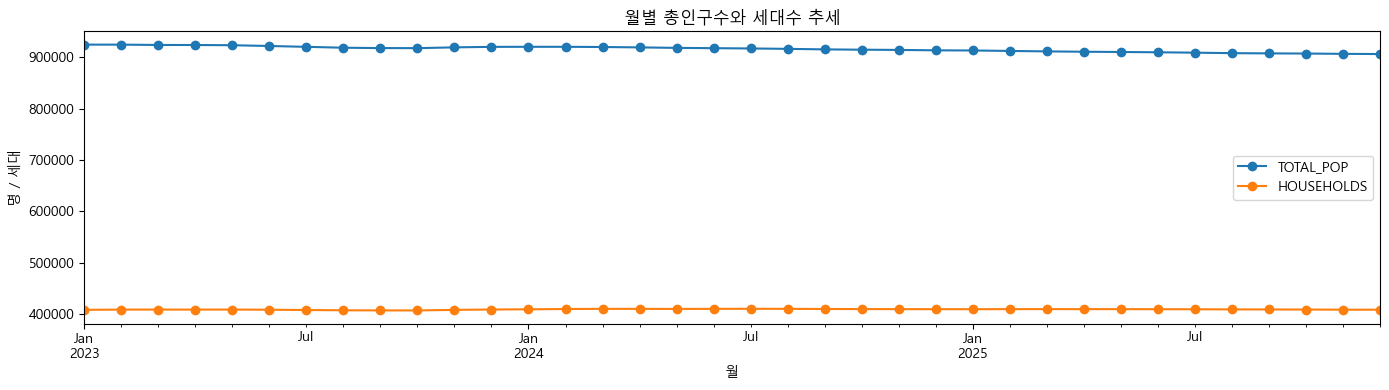

In [90]:
ax = population_monthly.plot(
    x="BASE_MONTH",
    y=["TOTAL_POP", "HOUSEHOLDS"],
    figsize=(14, 4),
    marker="o",
    title="월별 총인구수와 세대수 추세",
)
ax.set_xlabel("월")
ax.set_ylabel("명 / 세대")
plt.tight_layout()
plt.show()


**그래프 설명 - 월별 총인구수와 세대수 추세**

전체 인구와 세대수가 시간에 따라 어떻게 변하는지 확인합니다. 인구는 줄지만 세대수가 늘면 1인 가구 증가나 세대 분화 가능성을 의심할 수 있고, 두 지표가 함께 증가하면 주거 수요 확대 신호로 볼 수 있습니다.


In [91]:
latest_month = population_clean["BASE_MONTH"].max()
latest_population = population_clean[population_clean["BASE_MONTH"] == latest_month].copy()

latest_by_cty = (
    latest_population.groupby("CTY_NM", as_index=False)
    .agg(
        TOTAL_POP=("TOTAL_POP", "sum"),
        HOUSEHOLDS=("HOUSEHOLDS", "sum"),
        AVG_HOUSEHOLD_SIZE=("HOUSEHOLD_SIZE", "mean"),
        ADMI_COUNT=("ADMI_CD", "nunique"),
    )
    .sort_values("TOTAL_POP", ascending=False)
)
latest_by_cty


,CTY_NM,TOTAL_POP,HOUSEHOLDS,AVG_HOUSEHOLD_SIZE,ADMI_COUNT
0,성남시 분당구,469833,193385,2.475455,22
1,성남시 수정구,232389,116200,1.938235,17
2,성남시 중원구,203572,99667,2.062727,11


**데이터프레임 설명 - `latest_by_cty`**

가장 최근 월 기준 구별 인구·세대 요약입니다. 구별 인구 규모를 비교할 때 사용하며, `AVG_HOUSEHOLD_SIZE`가 낮은 구는 상대적으로 소형 세대 또는 1인 가구 비중이 높을 가능성이 있습니다.

핵심 설명: 이 표는 이후 그래프를 해석하기 위한 기준 데이터입니다. 행 수, 기간, 지역 단위, 비중·변화율 컬럼을 먼저 확인하고 그래프를 읽으면 됩니다.


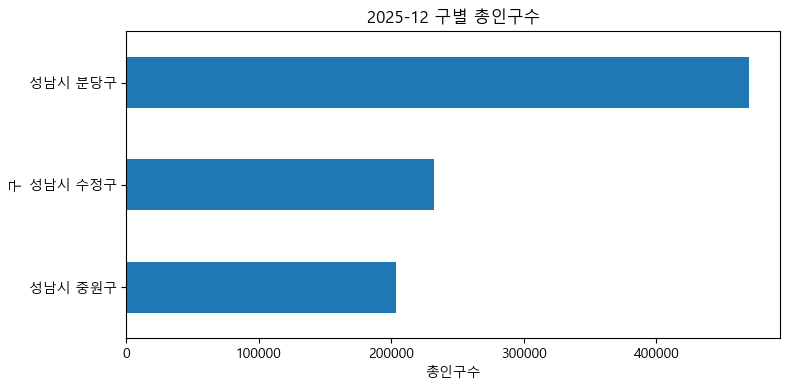

In [92]:
ax = latest_by_cty.sort_values("TOTAL_POP").plot(
    kind="barh",
    x="CTY_NM",
    y="TOTAL_POP",
    figsize=(8, 4),
    legend=False,
    title=f"{latest_month:%Y-%m} 구별 총인구수",
)
ax.set_xlabel("총인구수")
ax.set_ylabel("구")
plt.tight_layout()
plt.show()


**그래프 설명 - 최근 월 구별 총인구수**

최근 월 기준으로 어느 구의 등록 인구 규모가 큰지 비교합니다. 이후 t 데이터의 유동·방문 규모를 볼 때, 인구가 많은 구라서 총량이 큰 것인지 인구 대비 활동성이 높은 것인지 구분하는 기준이 됩니다.


In [93]:
admi_pop_rank = latest_population.sort_values("TOTAL_POP", ascending=False)
admi_pop_top_bottom = pd.concat([
    admi_pop_rank.head(10).assign(RANK_TYPE="인구 상위 10"),
    admi_pop_rank.tail(10).assign(RANK_TYPE="인구 하위 10"),
])
admi_pop_top_bottom[["RANK_TYPE", "CTY_NM", "ADMI_NM", "ADMI_CD", "TOTAL_POP", "HOUSEHOLDS", "HOUSEHOLD_SIZE"]]


,RANK_TYPE,CTY_NM,ADMI_NM,ADMI_CD,TOTAL_POP,HOUSEHOLDS,HOUSEHOLD_SIZE
1763,인구 상위 10,성남시 수정구,위례동,41131625,45473,18782,2.42
1799,인구 상위 10,성남시 분당구,운중동,41135680,38266,13960,2.74
1767,인구 상위 10,성남시 중원구,성남동,41133510,31835,18409,1.73
1751,인구 상위 10,성남시 수정구,신흥2동,41131520,31635,12313,2.57
1786,인구 상위 10,성남시 분당구,서현1동,41135580,30649,12678,2.42
1783,인구 상위 10,성남시 분당구,정자1동,41135550,30247,14055,2.15
1798,인구 상위 10,성남시 분당구,구미동,41135670,27981,12636,2.21
1796,인구 상위 10,성남시 분당구,금곡동,41135662,26767,11997,2.23
1792,인구 상위 10,성남시 분당구,야탑3동,41135640,26618,12711,2.09
1793,인구 상위 10,성남시 분당구,판교동,41135650,26365,8979,2.94


**데이터프레임 설명 - `admi_pop_top_bottom`**

최근 월 기준 행정동별 인구 상위·하위 10개입니다. 같은 구 안에서도 행정동별 인구 기반이 크게 다를 수 있으므로, 유동인구 TOP 지역과 비교할 때 유용합니다.

핵심 설명: 이 표는 이후 그래프를 해석하기 위한 기준 데이터입니다. 행 수, 기간, 지역 단위, 비중·변화율 컬럼을 먼저 확인하고 그래프를 읽으면 됩니다.


In [94]:
start_month = population_clean["BASE_MONTH"].min()
end_month = population_clean["BASE_MONTH"].max()

pop_start = (
    population_clean[population_clean["BASE_MONTH"] == start_month]
    [["ADMI_CD", "CTY_NM", "ADMI_NM", "TOTAL_POP", "HOUSEHOLDS", "HOUSEHOLD_SIZE"]]
    .rename(columns={
        "TOTAL_POP": "START_POP",
        "HOUSEHOLDS": "START_HOUSEHOLDS",
        "HOUSEHOLD_SIZE": "START_HOUSEHOLD_SIZE",
    })
)
pop_end = (
    population_clean[population_clean["BASE_MONTH"] == end_month]
    [["ADMI_CD", "TOTAL_POP", "HOUSEHOLDS", "HOUSEHOLD_SIZE"]]
    .rename(columns={
        "TOTAL_POP": "END_POP",
        "HOUSEHOLDS": "END_HOUSEHOLDS",
        "HOUSEHOLD_SIZE": "END_HOUSEHOLD_SIZE",
    })
)

population_change = pop_start.merge(pop_end, on="ADMI_CD", how="inner")
population_change["POP_CHANGE"] = population_change["END_POP"] - population_change["START_POP"]
population_change["POP_CHANGE_PCT"] = population_change["POP_CHANGE"] / population_change["START_POP"]
population_change["HOUSEHOLDS_CHANGE"] = population_change["END_HOUSEHOLDS"] - population_change["START_HOUSEHOLDS"]
population_change["HOUSEHOLD_SIZE_CHANGE"] = population_change["END_HOUSEHOLD_SIZE"] - population_change["START_HOUSEHOLD_SIZE"]
population_change.sort_values("POP_CHANGE", ascending=False)


,ADMI_CD,CTY_NM,ADMI_NM,START_POP,START_HOUSEHOLDS,START_HOUSEHOLD_SIZE,END_POP,END_HOUSEHOLDS,END_HOUSEHOLD_SIZE,POP_CHANGE,POP_CHANGE_PCT,HOUSEHOLDS_CHANGE,HOUSEHOLD_SIZE_CHANGE
31,41131520,성남시 수정구,신흥2동,19870,7612,2.61,31635,12313,2.57,11765,0.592099,4701,-0.04
14,41135680,성남시 분당구,운중동,33353,11990,2.78,38266,13960,2.74,4913,0.147303,1970,-0.04
39,41133530,성남시 중원구,금광1동,16762,7156,2.34,19608,8241,2.38,2846,0.169789,1085,0.04
34,41131625,성남시 수정구,위례동,43003,17258,2.49,45473,18782,2.42,2470,0.057438,1524,-0.07
22,41131640,성남시 수정구,고등동,10753,4763,2.26,11797,5320,2.22,1044,0.097089,557,-0.04
28,41131650,성남시 수정구,시흥동,3389,1967,1.72,3548,2162,1.64,159,0.046916,195,-0.08
17,41135550,성남시 분당구,정자1동,30125,13906,2.17,30247,14055,2.15,122,0.004050,149,-0.02
48,41133525,성남시 중원구,중앙동,16514,7555,2.19,16585,7518,2.21,71,0.004299,-37,0.02
8,41135520,성남시 분당구,수내1동,17911,7807,2.29,17879,7886,2.27,-32,-0.001787,79,-0.02
9,41135530,성남시 분당구,수내2동,10416,3194,3.26,10381,3194,3.25,-35,-0.003360,0,-0.01


**데이터프레임 설명 - `population_change`**

첫 월과 마지막 월을 비교한 행정동별 인구 변화표입니다. `POP_CHANGE`는 순증감 인구수, `POP_CHANGE_PCT`는 시작 월 대비 변화율입니다. 인구는 줄었는데 세대수가 늘어난 지역은 세대 규모 축소 가능성이 있습니다.

핵심 설명: 이 표는 이후 그래프를 해석하기 위한 기준 데이터입니다. 행 수, 기간, 지역 단위, 비중·변화율 컬럼을 먼저 확인하고 그래프를 읽으면 됩니다.


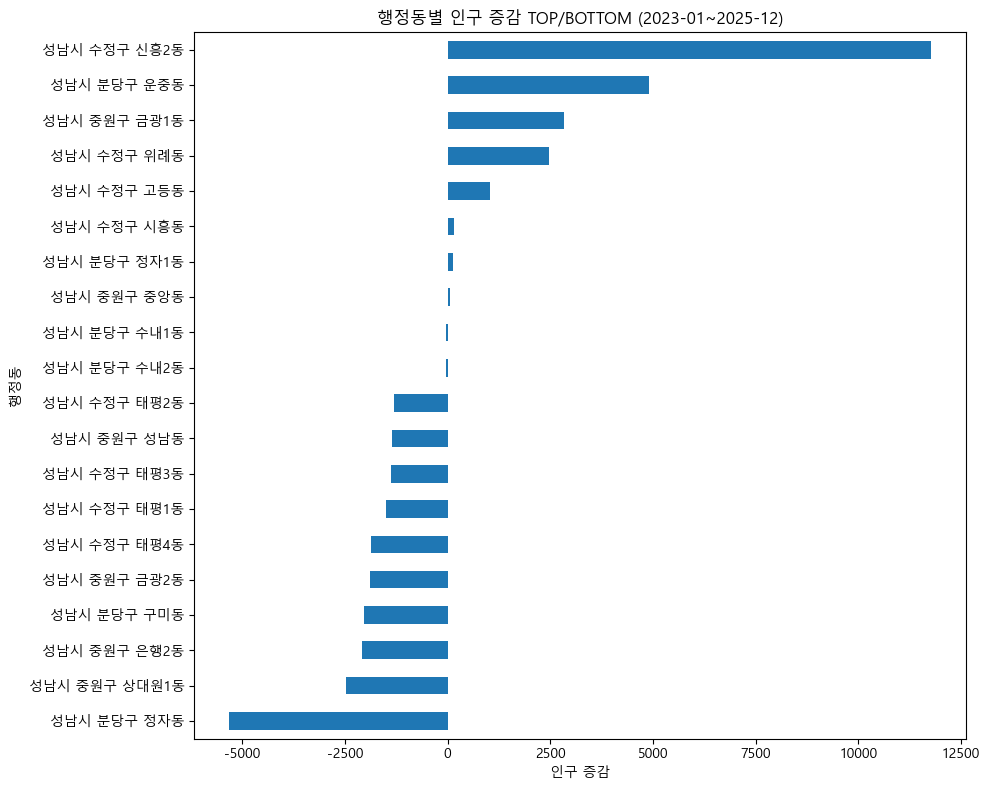

In [95]:
pop_change_plot = pd.concat([
    population_change.nlargest(10, "POP_CHANGE"),
    population_change.nsmallest(10, "POP_CHANGE"),
]).copy()
pop_change_plot["LABEL"] = pop_change_plot["CTY_NM"] + " " + pop_change_plot["ADMI_NM"]

ax = pop_change_plot.sort_values("POP_CHANGE").plot(
    kind="barh",
    x="LABEL",
    y="POP_CHANGE",
    figsize=(10, 8),
    legend=False,
    title=f"행정동별 인구 증감 TOP/BOTTOM ({start_month:%Y-%m}~{end_month:%Y-%m})",
)
ax.set_xlabel("인구 증감")
ax.set_ylabel("행정동")
plt.tight_layout()
plt.show()


**그래프 설명 - 행정동별 인구 증감 TOP/BOTTOM**

분석 기간 동안 인구가 가장 많이 늘어난 행정동과 가장 많이 줄어든 행정동을 함께 보여줍니다. 유동인구 증가 지역이 실제 거주 인구 증가 지역인지, 아니면 방문·통행 증가 지역인지 구분하는 데 활용합니다.


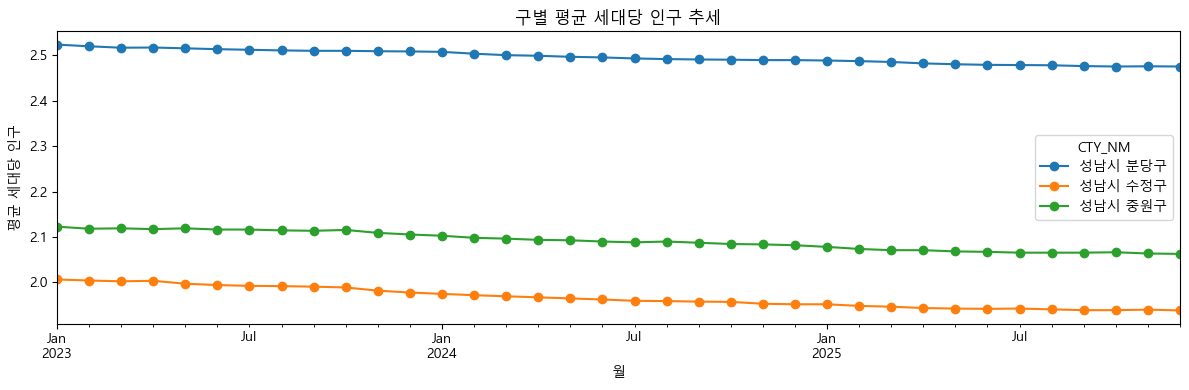

In [96]:
household_size_by_cty = (
    population_clean.groupby(["BASE_MONTH", "CTY_NM"], as_index=False)
    .agg(AVG_HOUSEHOLD_SIZE=("HOUSEHOLD_SIZE", "mean"))
)
household_size_pivot = household_size_by_cty.pivot(index="BASE_MONTH", columns="CTY_NM", values="AVG_HOUSEHOLD_SIZE")

ax = household_size_pivot.plot(figsize=(12, 4), marker="o", title="구별 평균 세대당 인구 추세")
ax.set_xlabel("월")
ax.set_ylabel("평균 세대당 인구")
plt.tight_layout()
plt.show()


**그래프 설명 - 구별 평균 세대당 인구 추세**

구별 세대 규모가 시간에 따라 줄어드는지 확인합니다. 세대당 인구가 지속적으로 낮아지면 1~2인 가구 증가, 주거 구성 변화, 생활 서비스 수요 변화와 연결해서 볼 수 있습니다.


In [97]:
if RUN_MONTHLY_ADMIN_ALL_T and all(name in globals() for name in ["T_DATA_FILES", "table_columns", "q", "union_query", "qname", "cnt_expr", "scan_sql"]):
    admin_code_columns = ["ADMI_CD", "D_ADMI_CD", "O_ADMI_CD"]
    admin_parts = []

    for table_id in T_DATA_FILES:
        cols = table_columns(table_id)
        for col in admin_code_columns:
            if col not in cols:
                continue
            if col.startswith("O_"):
                role = "출발행정동"
            elif col.startswith("D_"):
                role = "도착행정동"
            else:
                role = "행정동"
            admin_parts.append(f'''
                SELECT
                    '{table_id}' AS TABLE_ID,
                    '{role}' AS ADMIN_ROLE,
                    TRY_CAST({qname(col)} AS BIGINT) AS ADMI_CD,
                    SUM({cnt_expr(table_id)}) AS CNT_SUM
                FROM {scan_sql(table_id)}
                WHERE TRY_CAST({qname(col)} AS BIGINT) IS NOT NULL
                GROUP BY 1, 2, 3
            ''')

    all_t_admin = q(union_query(admin_parts)).sort_values("CNT_SUM", ascending=False)

    latest_population_key = latest_population[["ADMI_CD", "CTY_NM", "ADMI_NM", "TOTAL_POP", "HOUSEHOLDS", "HOUSEHOLD_SIZE"]]
    all_t_admin_population = all_t_admin.merge(latest_population_key, on="ADMI_CD", how="inner")
    all_t_admin_population["CNT_PER_PERSON"] = all_t_admin_population["CNT_SUM"] / all_t_admin_population["TOTAL_POP"]
    all_t_admin_population["CNT_PER_HOUSEHOLD"] = all_t_admin_population["CNT_SUM"] / all_t_admin_population["HOUSEHOLDS"]
    all_t_admin_population.sort_values("CNT_PER_PERSON", ascending=False).head(30)
else:
    all_t_admin_population = pd.DataFrame(columns=[
        "TABLE_ID", "ADMIN_ROLE", "ADMI_CD", "CNT_SUM", "CTY_NM", "ADMI_NM",
        "TOTAL_POP", "HOUSEHOLDS", "HOUSEHOLD_SIZE", "CNT_PER_PERSON", "CNT_PER_HOUSEHOLD"
    ])
    pd.DataFrame({
        "안내": [
            "전체 t 데이터 결합 셀입니다. 첫 셀에서 RUN_MONTHLY_ADMIN_ALL_T=True로 바꾸고 앞쪽 준비 셀을 실행하면 결과가 생성됩니다.",
            "월별 행정동 시각화만 보려면 아래의 빠른 t24 월별 행정동 패널부터 실행해도 됩니다."
        ]
    })


**데이터프레임 설명 - `all_t_admin_population`**

행정동 코드가 있는 전체 t 테이블 집계와 최근 월 인구 데이터를 결합한 표입니다. `CNT_PER_PERSON`은 등록인구 1명당 t 데이터 관측 규모로, 실제 개인별 방문 횟수가 아니라 지역 규모를 보정한 비교 지표입니다. 외부 유입이 많은 지역은 이 값이 높게 나올 수 있습니다.

핵심 설명: 이 표는 이후 그래프를 해석하기 위한 기준 데이터입니다. 행 수, 기간, 지역 단위, 비중·변화율 컬럼을 먼저 확인하고 그래프를 읽으면 됩니다.


In [98]:
if all_t_admin_population.empty:
    pd.DataFrame({"안내": ["all_t_admin_population이 비어 있습니다. 전체 t 데이터 EDA 준비 셀을 실행한 뒤 다시 실행하세요."]})
else:
    admin_pop_top30 = all_t_admin_population.sort_values("CNT_PER_PERSON", ascending=False).head(30).copy()
    admin_pop_top30["LABEL"] = (
        admin_pop_top30["TABLE_ID"] + " | "
        + admin_pop_top30["ADMIN_ROLE"] + " | "
        + admin_pop_top30["CTY_NM"] + " "
        + admin_pop_top30["ADMI_NM"]
    )

    ax = admin_pop_top30.sort_values("CNT_PER_PERSON").plot(
        kind="barh",
        x="LABEL",
        y="CNT_PER_PERSON",
        figsize=(12, 10),
        legend=False,
        title="인구 대비 t 데이터 관측 규모 TOP 30",
    )
    ax.set_xlabel("CNT / 등록인구")
    ax.set_ylabel("테이블 | 역할 | 행정동")
    plt.tight_layout()
    plt.show()


**그래프 설명 - 인구 대비 t 데이터 관측 규모 TOP 30**

인구가 많은 지역이 총량에서 유리한 문제를 줄이기 위해 `CNT_SUM`을 최근 월 등록인구로 나눈 그래프입니다. 값이 높은 지역은 거주 인구 대비 유동·방문·이동 관측이 많은 지역으로 볼 수 있으며, 상권·교통 중심지 또는 외부 유입 지역 후보입니다.


In [99]:
population_feature_table = pd.DataFrame([
    ["TOTAL_POP", "총인구수에서 쉼표 제거 후 정수 변환", "행정동별 등록 인구 규모", "구/동별 인구 기반 비교"],
    ["HOUSEHOLDS", "세대수에서 쉼표 제거 후 정수 변환", "행정동별 세대 규모", "세대 증가와 인구 증가 비교"],
    ["HOUSEHOLD_SIZE", "세대당_인구 실수형 변환", "세대당 평균 인구", "1~2인 가구 증가 가능성 확인"],
    ["BASE_MONTH", "날짜 + '-01'을 datetime 변환", "월 단위 기준일", "월별 추세와 t 데이터 월 집계 결합"],
    ["YEAR_MONTH", "BASE_MONTH를 YYYY-MM 문자열로 변환", "월 표시용 라벨", "그래프 x축과 월별 피벗"],
    ["ADMI_CD", "10자리 행정동 코드 // 100", "t 데이터와 결합 가능한 8자리 행정동 코드", "인구 대비 t 관측 규모 계산"],
    ["CTY_NM", "행정구역 문자열에서 시+구 추출", "구 단위 지역명", "구별 인구/세대 비교"],
    ["ADMI_NM", "행정구역 문자열 마지막 토큰", "행정동명", "행정동 순위와 변화 분석"],
    ["POP_MOM_PCT", "TOTAL_POP.pct_change()", "전월 대비 인구 변화율", "월별 인구 급변 확인"],
    ["POP_CHANGE", "마지막 월 인구 - 첫 월 인구", "기간 전체 인구 순증감", "증가/감소 행정동 탐색"],
    ["POP_CHANGE_PCT", "POP_CHANGE / 첫 월 인구", "기간 전체 인구 변화율", "규모가 다른 행정동 비교"],
    ["CNT_PER_PERSON", "t CNT_SUM / 최근 월 TOTAL_POP", "인구 1명당 t 관측 규모", "거주 인구 대비 유동·방문 강도 비교"],
], columns=["파생변수", "생성 기준", "의미", "EDA 활용"])

population_feature_table


,파생변수,생성 기준,의미,EDA 활용
0,TOTAL_POP,총인구수에서 쉼표 제거 후 정수 변환,행정동별 등록 인구 규모,구/동별 인구 기반 비교
1,HOUSEHOLDS,세대수에서 쉼표 제거 후 정수 변환,행정동별 세대 규모,세대 증가와 인구 증가 비교
2,HOUSEHOLD_SIZE,세대당_인구 실수형 변환,세대당 평균 인구,1~2인 가구 증가 가능성 확인
3,BASE_MONTH,날짜 + '-01'을 datetime 변환,월 단위 기준일,월별 추세와 t 데이터 월 집계 결합
4,YEAR_MONTH,BASE_MONTH를 YYYY-MM 문자열로 변환,월 표시용 라벨,그래프 x축과 월별 피벗
5,ADMI_CD,10자리 행정동 코드 // 100,t 데이터와 결합 가능한 8자리 행정동 코드,인구 대비 t 관측 규모 계산
6,CTY_NM,행정구역 문자열에서 시+구 추출,구 단위 지역명,구별 인구/세대 비교
7,ADMI_NM,행정구역 문자열 마지막 토큰,행정동명,행정동 순위와 변화 분석
8,POP_MOM_PCT,TOTAL_POP.pct_change(),전월 대비 인구 변화율,월별 인구 급변 확인
9,POP_CHANGE,마지막 월 인구 - 첫 월 인구,기간 전체 인구 순증감,증가/감소 행정동 탐색


**데이터프레임 설명 - `population_feature_table`**

인구 데이터 EDA에서 새로 만든 파생변수의 의미표입니다. 핵심은 `ADMI_CD`로 t 데이터와 인구 데이터를 연결하고, `CNT_PER_PERSON`으로 지역 인구 규모를 보정해 비교하는 것입니다.

핵심 설명: 이 표는 이후 그래프를 해석하기 위한 기준 데이터입니다. 행 수, 기간, 지역 단위, 비중·변화율 컬럼을 먼저 확인하고 그래프를 읽으면 됩니다.


## 빠른 시각화용 t24 월별 행정동 패널

전체 t 테이블을 모두 집계하는 `monthly_admin_panel`은 가장 완전하지만 실행 시간이 오래 걸릴 수 있습니다. 아래 셀은 팀 기준인 월별 행정동 단위를 유지하면서, 기본 예시인 `t24`만 먼저 집계해 시각화를 빠르게 확인하기 위한 패널입니다.

이 셀을 실행하면 뒤의 시각화 모음은 `t24` 기준으로 바로 그릴 수 있습니다.


In [100]:
if "con" not in globals():
    con = duckdb.connect()

if "scan_sql" not in globals():
    def scan_sql(table_id):
        file_map = {
            "t24": "t24_2023_2025_all_date_final.parquet",
        }
        return f"read_parquet('{(DATA_DIR / file_map[table_id]).as_posix()}')"

if "q" not in globals():
    def q(sql):
        return con.execute(sql).df()

t24_monthly_admin_panel = q(f'''
    SELECT
        't24' AS TABLE_ID,
        '행정동' AS ADMIN_ROLE,
        CAST(date_trunc('month', CAST(ETL_YMD AS DATE)) AS DATE) AS BASE_MONTH,
        CAST(ADMI_CD AS BIGINT) AS ADMI_CD,
        SUM(CNT) AS CNT_SUM
    FROM {scan_sql("t24")}
    GROUP BY 1, 2, 3, 4
''')

t24_monthly_admin_panel["BASE_MONTH"] = pd.to_datetime(t24_monthly_admin_panel["BASE_MONTH"])
t24_monthly_admin_panel["YEAR_MONTH"] = t24_monthly_admin_panel["BASE_MONTH"].dt.strftime("%Y-%m")

t24_monthly_admin_panel = t24_monthly_admin_panel.merge(
    population_clean[
        ["BASE_MONTH", "YEAR_MONTH", "ADMI_CD", "CTY_NM", "ADMI_NM", "TOTAL_POP", "HOUSEHOLDS", "HOUSEHOLD_SIZE"]
    ],
    on=["BASE_MONTH", "YEAR_MONTH", "ADMI_CD"],
    how="inner",
)

t24_monthly_admin_panel["CNT_PER_PERSON"] = t24_monthly_admin_panel["CNT_SUM"] / t24_monthly_admin_panel["TOTAL_POP"]
t24_monthly_admin_panel["CNT_PER_1K_POP"] = t24_monthly_admin_panel["CNT_PER_PERSON"] * 1000
t24_monthly_admin_panel["CNT_PER_HOUSEHOLD"] = t24_monthly_admin_panel["CNT_SUM"] / t24_monthly_admin_panel["HOUSEHOLDS"]

t24_monthly_admin_panel = t24_monthly_admin_panel.sort_values(["ADMI_CD", "BASE_MONTH"])
t24_monthly_admin_panel["CNT_MOM_CHANGE"] = t24_monthly_admin_panel.groupby("ADMI_CD")["CNT_SUM"].diff()
t24_monthly_admin_panel["CNT_MOM_PCT"] = t24_monthly_admin_panel.groupby("ADMI_CD")["CNT_SUM"].pct_change()
t24_monthly_admin_panel["CNT_PER_PERSON_MOM_PCT"] = t24_monthly_admin_panel.groupby("ADMI_CD")["CNT_PER_PERSON"].pct_change()
t24_monthly_admin_panel["CNT_PER_PERSON_MA3"] = (
    t24_monthly_admin_panel.groupby("ADMI_CD")["CNT_PER_PERSON"]
    .transform(lambda s: s.rolling(3, min_periods=1).mean())
)

focus_table_id = "t24"
focus_admin_role = "행정동"
focus_monthly_admin = t24_monthly_admin_panel.copy()

monthly_admin_outliers = (
    focus_monthly_admin.dropna(subset=["CNT_PER_PERSON_MOM_PCT"])
    .assign(ABS_MOM_PCT=lambda df: df["CNT_PER_PERSON_MOM_PCT"].abs())
    .sort_values("ABS_MOM_PCT", ascending=False)
)

t24_monthly_admin_panel.head()


,TABLE_ID,ADMIN_ROLE,BASE_MONTH,ADMI_CD,CNT_SUM,YEAR_MONTH,CTY_NM,ADMI_NM,TOTAL_POP,HOUSEHOLDS,HOUSEHOLD_SIZE,CNT_PER_PERSON,CNT_PER_1K_POP,CNT_PER_HOUSEHOLD,CNT_MOM_CHANGE,CNT_MOM_PCT,CNT_PER_PERSON_MOM_PCT,CNT_PER_PERSON_MA3
1344,t24,행정동,2023-01-01,41131510,246945.16,2023-01,성남시 수정구,신흥1동,13150,7928,1.66,18.779100,18779.099620,31.148481,NaN,NaN,NaN,18.779100
1132,t24,행정동,2023-02-01,41131510,247386.29,2023-02,성남시 수정구,신흥1동,13116,7931,1.65,18.861413,18861.412778,31.192320,441.13,0.001786,0.004383,18.820256
1139,t24,행정동,2023-03-01,41131510,287471.98,2023-03,성남시 수정구,신흥1동,13106,7917,1.66,21.934380,21934.379673,36.310721,40085.69,0.162037,0.162923,19.858297
1606,t24,행정동,2023-04-01,41131510,267832.53,2023-04,성남시 수정구,신흥1동,13063,7892,1.66,20.503141,20503.140932,33.937219,-19639.45,-0.068318,-0.065251,20.432978
1352,t24,행정동,2023-05-01,41131510,275691.61,2023-05,성남시 수정구,신흥1동,13026,7889,1.65,21.164717,21164.717488,34.946332,7859.08,0.029343,0.032267,21.200746


**데이터프레임 설명 - `t24_monthly_admin_panel`**

`t24`만 월별 행정동 단위로 집계하고 인구 데이터를 붙인 빠른 시각화용 패널입니다. 전체 t 데이터 통합 분석 전에도 이 표로 행정동별 월별 유동 규모, 인구 보정 지표, 전월 대비 변화율을 바로 확인할 수 있습니다.

핵심 설명: 팀 분석의 기준 테이블입니다. 월별·행정동별로 인구 보정 유동 규모와 변화율을 비교할 때 이 표를 중심으로 해석하면 됩니다.


# 월별 행정동 단위 통합 EDA

팀 분석 기준을 **월별 행정동 단위**로 맞춥니다. 이 섹션에서는 전체 t 데이터 중 행정동 코드가 있는 테이블을 월(`BASE_MONTH`)과 행정동(`ADMI_CD`) 기준으로 집계한 뒤, `population_total.csv`의 월별 행정동 인구와 결합합니다.

핵심 해석 기준은 아래와 같습니다.

| 기준 | 의미 | 왜 필요한가 |
|---|---|---|
| 월별 | 일별 변동을 월 단위로 완화 | 휴일·요일·단기 이벤트 영향을 줄이고 추세를 보기 좋음 |
| 행정동 | 가장 세밀한 공통 공간 단위 | 구 단위보다 실제 지역 차이를 잘 보여줌 |
| 테이블/역할 분리 | `t24`, `t26`, 출발/도착 등 정의를 보존 | 서로 다른 의미의 데이터를 섞어 잘못 해석하는 것을 방지 |
| 인구 대비 지표 | `CNT / TOTAL_POP` | 인구가 많은 동이 무조건 커 보이는 문제를 보정 |
| 전월 대비 변화율 | 이번 달이 지난달보다 얼마나 변했는지 | 급증·급감 행정동을 찾기 쉬움 |

주의할 점은 `CNT_PER_PERSON`이 실제 1인당 방문 횟수를 뜻하는 것은 아니라는 점입니다. t 데이터의 `CNT`는 테이블 정의별 관측 규모이므로, 이 지표는 **등록인구 대비 상대적 유동/이동 강도**로 해석합니다.


In [101]:
if RUN_MONTHLY_ADMIN_ALL_T:
    monthly_admin_parts = []
    admin_code_columns = ["ADMI_CD", "D_ADMI_CD", "O_ADMI_CD"]

    for table_id in T_DATA_FILES:
        cols = table_columns(table_id)
        d = date_expr(table_id)
        if d is None:
            continue

        for col in admin_code_columns:
            if col not in cols:
                continue

            if col.startswith("O_"):
                role = "출발행정동"
            elif col.startswith("D_"):
                role = "도착행정동"
            else:
                role = "행정동"

            monthly_admin_parts.append(f'''
                SELECT
                    '{table_id}' AS TABLE_ID,
                    '{role}' AS ADMIN_ROLE,
                    CAST(date_trunc('month', {d}) AS DATE) AS BASE_MONTH,
                    TRY_CAST({qname(col)} AS BIGINT) AS ADMI_CD,
                    SUM({cnt_expr(table_id)}) AS CNT_SUM
                FROM {scan_sql(table_id)}
                WHERE TRY_CAST({qname(col)} AS BIGINT) IS NOT NULL
                GROUP BY 1, 2, 3, 4
            ''')

    monthly_admin_t = q(union_query(monthly_admin_parts))
    monthly_admin_t["BASE_MONTH"] = pd.to_datetime(monthly_admin_t["BASE_MONTH"])
    monthly_admin_t["YEAR_MONTH"] = monthly_admin_t["BASE_MONTH"].dt.strftime("%Y-%m")
    monthly_admin_t.head()
else:
    monthly_admin_t = pd.DataFrame()
    pd.DataFrame({"안내": ["전체 t 월별 행정동 집계는 전체 t 월별 행정동 스캔이라 기본 실행을 건너뜁니다.", "필요하면 첫 셀에서 RUN_MONTHLY_ADMIN_ALL_T = True로 바꾸고 다시 실행하세요."]})


**데이터프레임 설명 - `monthly_admin_t`**

전체 t 데이터에서 행정동 코드가 있는 테이블만 월별·행정동별로 집계한 결과입니다. 한 행은 `TABLE_ID`, `ADMIN_ROLE`, `BASE_MONTH`, `ADMI_CD` 조합의 `CNT_SUM`입니다. `ADMIN_ROLE`은 출발 행정동인지, 도착 행정동인지, 단일 행정동 기준인지 구분합니다.

핵심 설명: t 데이터만 월별 행정동 단위로 맞춘 중간 집계입니다. 여기에 인구를 붙이면 최종 분석 패널이 됩니다.


In [102]:
if "monthly_admin_t" not in globals() or (hasattr(monthly_admin_t, "empty") and monthly_admin_t.empty):
    pd.DataFrame({"안내": ["전체 t 월별 행정동 인구 결합는 대용량 셀을 건너뛰어서 실행하지 않습니다.", "월별 행정동 분석은 아래 빠른 t24 패널과 시각화 섹션을 사용하세요."]})
else:
    monthly_admin_panel = monthly_admin_t.merge(
        population_clean[
            ["BASE_MONTH", "YEAR_MONTH", "ADMI_CD", "CTY_NM", "ADMI_NM", "TOTAL_POP", "HOUSEHOLDS", "HOUSEHOLD_SIZE"]
        ],
        on=["BASE_MONTH", "YEAR_MONTH", "ADMI_CD"],
        how="inner",
    )

    monthly_admin_panel["CNT_PER_PERSON"] = monthly_admin_panel["CNT_SUM"] / monthly_admin_panel["TOTAL_POP"]
    monthly_admin_panel["CNT_PER_1K_POP"] = monthly_admin_panel["CNT_PER_PERSON"] * 1000
    monthly_admin_panel["CNT_PER_HOUSEHOLD"] = monthly_admin_panel["CNT_SUM"] / monthly_admin_panel["HOUSEHOLDS"]

    monthly_admin_panel = monthly_admin_panel.sort_values(["TABLE_ID", "ADMIN_ROLE", "ADMI_CD", "BASE_MONTH"])
    monthly_admin_panel["CNT_MOM_CHANGE"] = monthly_admin_panel.groupby(["TABLE_ID", "ADMIN_ROLE", "ADMI_CD"])["CNT_SUM"].diff()
    monthly_admin_panel["CNT_MOM_PCT"] = monthly_admin_panel.groupby(["TABLE_ID", "ADMIN_ROLE", "ADMI_CD"])["CNT_SUM"].pct_change()
    monthly_admin_panel["CNT_PER_PERSON_MOM_PCT"] = monthly_admin_panel.groupby(["TABLE_ID", "ADMIN_ROLE", "ADMI_CD"])["CNT_PER_PERSON"].pct_change()
    monthly_admin_panel["CNT_PER_PERSON_MA3"] = (
        monthly_admin_panel.groupby(["TABLE_ID", "ADMIN_ROLE", "ADMI_CD"])["CNT_PER_PERSON"]
        .transform(lambda s: s.rolling(3, min_periods=1).mean())
    )

    monthly_admin_panel.head()


**데이터프레임 설명 - `monthly_admin_panel`**

월별 행정동 t 집계에 같은 월의 행정동 인구를 붙인 핵심 분석 테이블입니다. 이 표를 기준으로 팀 분석을 진행하면 됩니다.

주요 컬럼 해석:

| 컬럼 | 의미 |
|---|---|
| `CNT_SUM` | 해당 월·행정동·테이블·역할의 전체 관측 규모 |
| `TOTAL_POP` | 같은 월·행정동의 등록 인구 |
| `CNT_PER_PERSON` | 인구 1명당 t 관측 규모 |
| `CNT_PER_1K_POP` | 인구 1,000명당 t 관측 규모 |
| `CNT_MOM_PCT` | 전월 대비 `CNT_SUM` 변화율 |
| `CNT_PER_PERSON_MOM_PCT` | 전월 대비 인구 보정 관측 규모 변화율 |
| `CNT_PER_PERSON_MA3` | 인구 보정 관측 규모의 3개월 이동평균 |

핵심 설명: 팀 분석의 기준 테이블입니다. 월별·행정동별로 인구 보정 유동 규모와 변화율을 비교할 때 이 표를 중심으로 해석하면 됩니다.


In [103]:
if "monthly_admin_panel" not in globals() or (hasattr(monthly_admin_panel, "empty") and monthly_admin_panel.empty):
    pd.DataFrame({"안내": ["전체 t 월별 행정동 커버리지는 대용량 셀을 건너뛰어서 실행하지 않습니다.", "월별 행정동 분석은 아래 빠른 t24 패널과 시각화 섹션을 사용하세요."]})
else:
    monthly_admin_coverage = (
        monthly_admin_panel.groupby(["TABLE_ID", "ADMIN_ROLE"], as_index=False)
        .agg(
            ROWS=("CNT_SUM", "size"),
            MONTH_COUNT=("BASE_MONTH", "nunique"),
            ADMI_COUNT=("ADMI_CD", "nunique"),
            CNT_SUM=("CNT_SUM", "sum"),
            AVG_CNT_PER_PERSON=("CNT_PER_PERSON", "mean"),
            MAX_CNT_PER_PERSON=("CNT_PER_PERSON", "max"),
        )
        .sort_values(["TABLE_ID", "ADMIN_ROLE"])
    )
    monthly_admin_coverage


**데이터프레임 설명 - `monthly_admin_coverage`**

월별 행정동 단위로 인구와 매칭된 t 테이블의 커버리지입니다. `MONTH_COUNT`가 36이면 2023-01~2025-12 전체 월이 잡힌 것이고, `ADMI_COUNT`가 50이면 인구 데이터의 50개 행정동과 모두 연결된 것입니다.

핵심 설명: 이 표는 이후 그래프를 해석하기 위한 기준 데이터입니다. 행 수, 기간, 지역 단위, 비중·변화율 컬럼을 먼저 확인하고 그래프를 읽으면 됩니다.


In [104]:
focus_table_id = "t24"
focus_admin_role = "행정동"

if "monthly_admin_panel" in globals():
    focus_monthly_admin = monthly_admin_panel[
        (monthly_admin_panel["TABLE_ID"] == focus_table_id)
        & (monthly_admin_panel["ADMIN_ROLE"] == focus_admin_role)
    ].copy()
elif "t24_monthly_admin_panel" in globals():
    focus_monthly_admin = t24_monthly_admin_panel.copy()
else:
    raise NameError("먼저 '빠른 시각화용 t24 월별 행정동 패널' 셀을 실행해 주세요.")

focus_monthly_admin.head()


,TABLE_ID,ADMIN_ROLE,BASE_MONTH,ADMI_CD,CNT_SUM,YEAR_MONTH,CTY_NM,ADMI_NM,TOTAL_POP,HOUSEHOLDS,HOUSEHOLD_SIZE,CNT_PER_PERSON,CNT_PER_1K_POP,CNT_PER_HOUSEHOLD,CNT_MOM_CHANGE,CNT_MOM_PCT,CNT_PER_PERSON_MOM_PCT,CNT_PER_PERSON_MA3
1344,t24,행정동,2023-01-01,41131510,246945.16,2023-01,성남시 수정구,신흥1동,13150,7928,1.66,18.779100,18779.099620,31.148481,NaN,NaN,NaN,18.779100
1132,t24,행정동,2023-02-01,41131510,247386.29,2023-02,성남시 수정구,신흥1동,13116,7931,1.65,18.861413,18861.412778,31.192320,441.13,0.001786,0.004383,18.820256
1139,t24,행정동,2023-03-01,41131510,287471.98,2023-03,성남시 수정구,신흥1동,13106,7917,1.66,21.934380,21934.379673,36.310721,40085.69,0.162037,0.162923,19.858297
1606,t24,행정동,2023-04-01,41131510,267832.53,2023-04,성남시 수정구,신흥1동,13063,7892,1.66,20.503141,20503.140932,33.937219,-19639.45,-0.068318,-0.065251,20.432978
1352,t24,행정동,2023-05-01,41131510,275691.61,2023-05,성남시 수정구,신흥1동,13026,7889,1.65,21.164717,21164.717488,34.946332,7859.08,0.029343,0.032267,21.200746


**설명 - 기본 확인 테이블 선택**

월별 행정동 EDA의 기본 예시는 `t24`를 사용합니다. `t24`는 행정동 단위 시간대별 목적 유동인구라서, 인구 데이터와 공간 단위가 잘 맞고 팀원들이 해석하기 쉽습니다. 다른 테이블을 보고 싶으면 `focus_table_id`, `focus_admin_role`만 바꾸면 같은 그래프를 재사용할 수 있습니다.


In [105]:
latest_focus_month = focus_monthly_admin["BASE_MONTH"].max()
latest_focus_admin = focus_monthly_admin[focus_monthly_admin["BASE_MONTH"] == latest_focus_month].copy()

latest_focus_top15 = latest_focus_admin.sort_values("CNT_PER_PERSON", ascending=False).head(15)
latest_focus_top15[
    ["YEAR_MONTH", "CTY_NM", "ADMI_NM", "TOTAL_POP", "CNT_SUM", "CNT_PER_PERSON", "CNT_PER_1K_POP"]
]


,YEAR_MONTH,CTY_NM,ADMI_NM,TOTAL_POP,CNT_SUM,CNT_PER_PERSON,CNT_PER_1K_POP
1786,2025-12,성남시 수정구,시흥동,3548,993159.13,279.920837,279920.837091
444,2025-12,성남시 분당구,삼평동,23593,3339736.32,141.556238,141556.237867
1333,2025-12,성남시 분당구,야탑1동,16525,2037033.84,123.269824,123269.823903
1790,2025-12,성남시 중원구,상대원2동,2911,320776.46,110.194593,110194.592923
443,2025-12,성남시 분당구,서현1동,30649,3025198.99,98.704656,98704.655617
1330,2025-12,성남시 분당구,정자1동,30247,2205120.34,72.903770,72903.770291
879,2025-12,성남시 분당구,수내1동,17879,1243483.97,69.549973,69549.973153
447,2025-12,성남시 수정구,복정동,10453,717709.92,68.660664,68660.663924
1792,2025-12,성남시 분당구,정자동,13750,907220.36,65.979663,65979.662545
884,2025-12,성남시 분당구,구미1동,16089,1053483.64,65.478503,65478.503325


**데이터프레임 설명 - `latest_focus_top15`**

최근 월 기준 인구 대비 유동인구 규모가 큰 행정동 TOP 15입니다. `CNT_SUM`이 큰 지역이 아니라 `CNT_PER_PERSON`이 큰 지역을 보는 이유는, 등록 인구 규모를 보정해 외부 유입·상권·교통 중심지 성격을 더 잘 보기 위해서입니다.

핵심 설명: 이 표는 이후 그래프를 해석하기 위한 기준 데이터입니다. 행 수, 기간, 지역 단위, 비중·변화율 컬럼을 먼저 확인하고 그래프를 읽으면 됩니다.


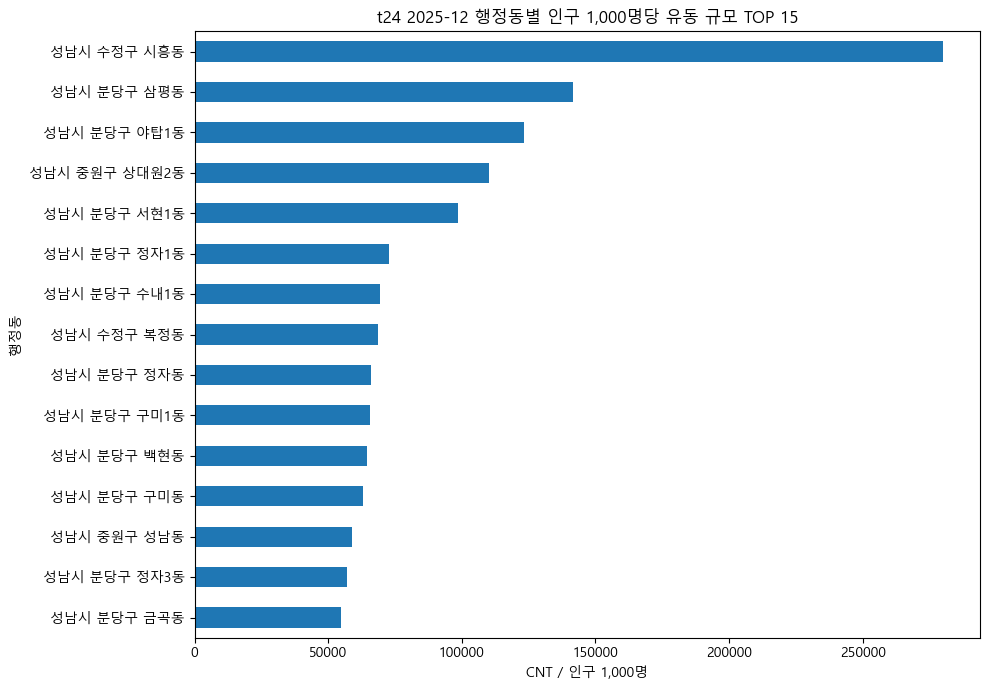

In [106]:
plot_df = latest_focus_top15.copy()
plot_df["LABEL"] = plot_df["CTY_NM"] + " " + plot_df["ADMI_NM"]

ax = plot_df.sort_values("CNT_PER_1K_POP").plot(
    kind="barh",
    x="LABEL",
    y="CNT_PER_1K_POP",
    figsize=(10, 7),
    legend=False,
    title=f"{focus_table_id} {latest_focus_month:%Y-%m} 행정동별 인구 1,000명당 유동 규모 TOP 15",
)
ax.set_xlabel("CNT / 인구 1,000명")
ax.set_ylabel("행정동")
plt.tight_layout()
plt.show()


**그래프 설명 - 최근 월 인구 1,000명당 유동 규모 TOP 15**

최근 월에 등록 인구 대비 유동 규모가 큰 행정동을 보여줍니다. 값이 높을수록 거주 인구보다 외부 방문·통행·활동 관측이 많은 지역일 가능성이 큽니다. 단, 테이블 정의가 `t24`이므로 “행정동 시간대별 목적 유동인구” 기준의 상대 강도로 해석합니다.


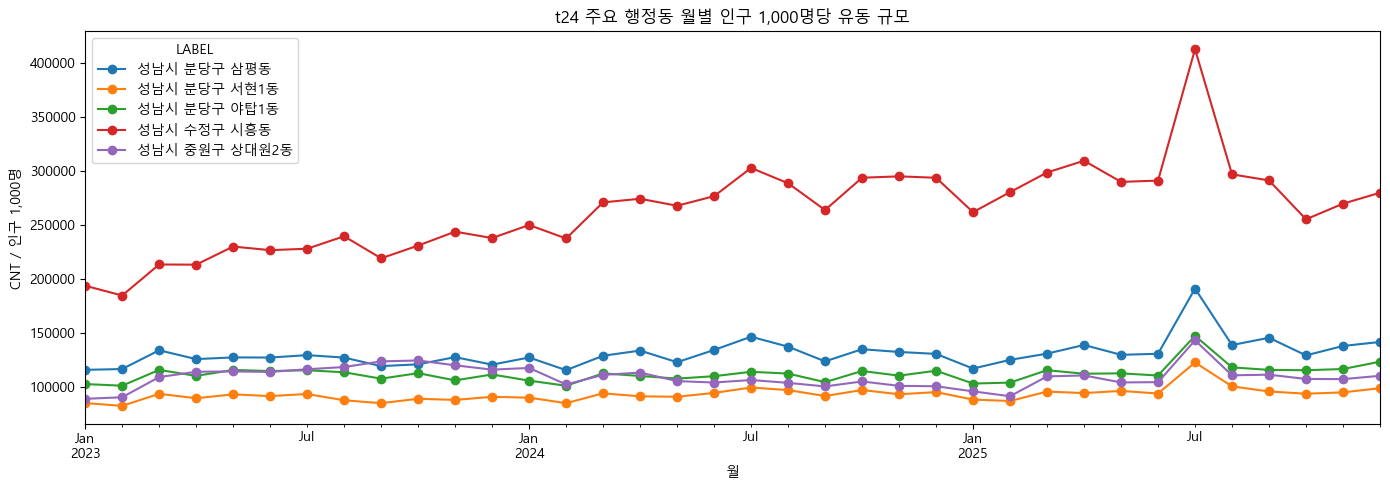

In [107]:
trend_admin_codes = latest_focus_top15["ADMI_CD"].head(5).tolist()
trend_df = focus_monthly_admin[focus_monthly_admin["ADMI_CD"].isin(trend_admin_codes)].copy()
trend_df["LABEL"] = trend_df["CTY_NM"] + " " + trend_df["ADMI_NM"]

trend_pivot = trend_df.pivot(index="BASE_MONTH", columns="LABEL", values="CNT_PER_1K_POP")
ax = trend_pivot.plot(figsize=(14, 5), marker="o", title=f"{focus_table_id} 주요 행정동 월별 인구 1,000명당 유동 규모")
ax.set_xlabel("월")
ax.set_ylabel("CNT / 인구 1,000명")
plt.tight_layout()
plt.show()


**그래프 설명 - 주요 행정동 월별 추세**

최근 월 상위 행정동 5개의 월별 추세입니다. 한 달만 높은 지역인지, 지속적으로 높은 지역인지 구분할 수 있습니다. 지속적으로 높으면 구조적인 중심지일 가능성이 있고, 특정 월만 튀면 이벤트나 계절 요인을 확인해야 합니다.


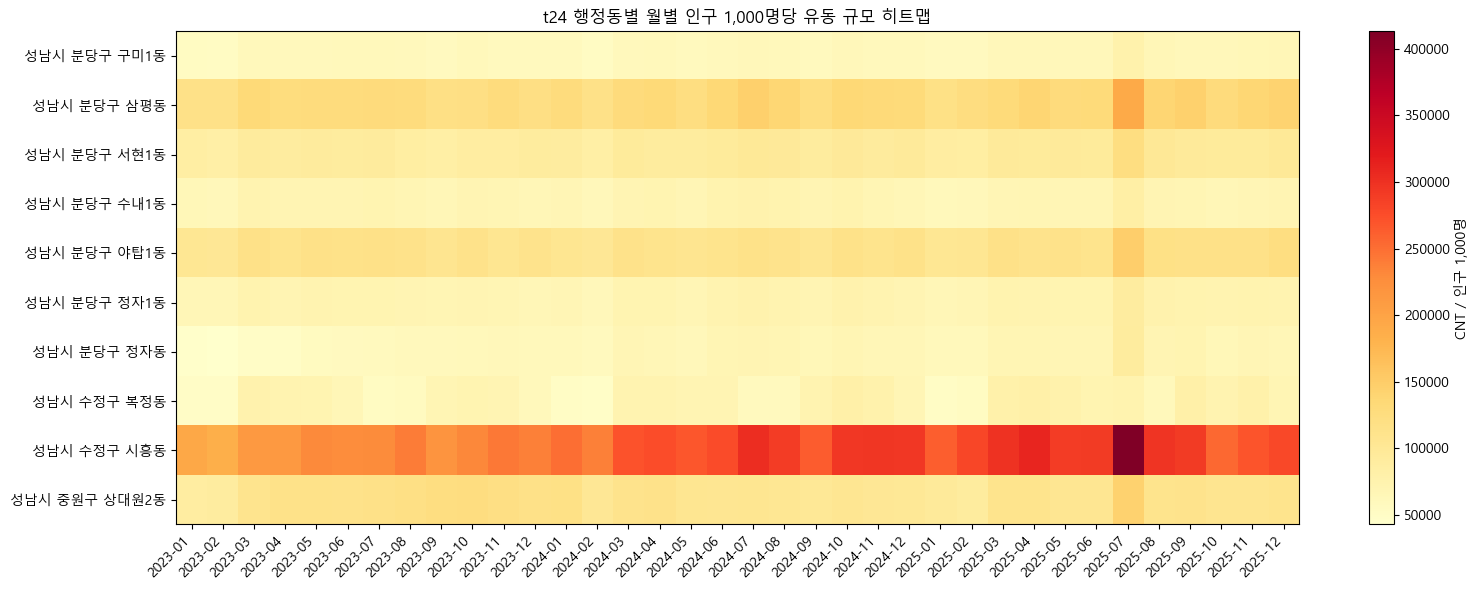

In [108]:
top10_admin_codes = latest_focus_top15["ADMI_CD"].head(10).tolist()
heatmap_df = focus_monthly_admin[focus_monthly_admin["ADMI_CD"].isin(top10_admin_codes)].copy()
heatmap_df["LABEL"] = heatmap_df["CTY_NM"] + " " + heatmap_df["ADMI_NM"]
heatmap_pivot = heatmap_df.pivot(index="LABEL", columns="YEAR_MONTH", values="CNT_PER_1K_POP")

fig, ax = plt.subplots(figsize=(16, 6))
im = ax.imshow(heatmap_pivot.values, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(len(heatmap_pivot.columns)))
ax.set_xticklabels(heatmap_pivot.columns, rotation=45, ha="right")
ax.set_yticks(range(len(heatmap_pivot.index)))
ax.set_yticklabels(heatmap_pivot.index)
ax.set_title(f"{focus_table_id} 행정동별 월별 인구 1,000명당 유동 규모 히트맵")
fig.colorbar(im, ax=ax, label="CNT / 인구 1,000명")
plt.tight_layout()
plt.show()


**그래프 설명 - 월별 행정동 히트맵**

행은 행정동, 열은 월입니다. 색이 진할수록 인구 대비 유동 규모가 큽니다. 히트맵은 특정 행정동이 어느 달에 강해지는지, 여러 행정동이 동시에 강해지는 계절 패턴이 있는지 빠르게 찾는 데 좋습니다.


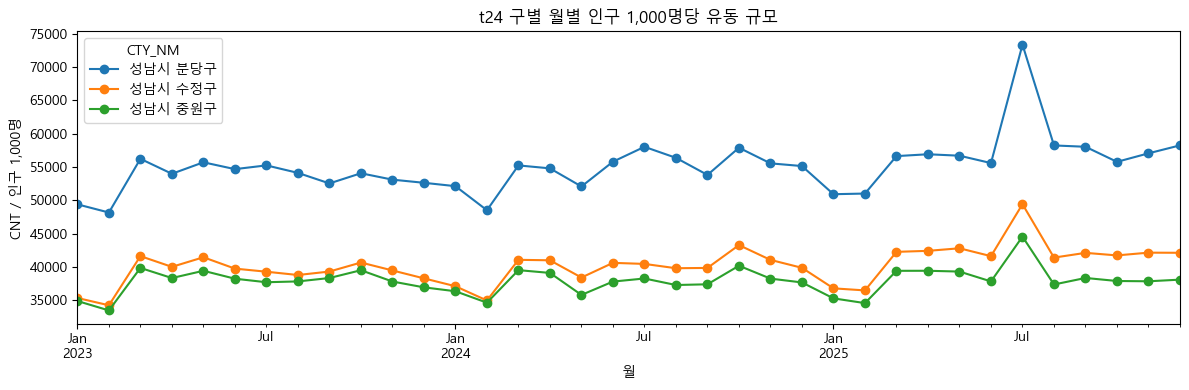

In [109]:
cty_monthly_panel = (
    focus_monthly_admin.groupby(["BASE_MONTH", "YEAR_MONTH", "CTY_NM"], as_index=False)
    .agg(
        CNT_SUM=("CNT_SUM", "sum"),
        TOTAL_POP=("TOTAL_POP", "sum"),
        HOUSEHOLDS=("HOUSEHOLDS", "sum"),
    )
)
cty_monthly_panel["CNT_PER_1K_POP"] = cty_monthly_panel["CNT_SUM"] / cty_monthly_panel["TOTAL_POP"] * 1000

cty_pivot = cty_monthly_panel.pivot(index="BASE_MONTH", columns="CTY_NM", values="CNT_PER_1K_POP")
ax = cty_pivot.plot(figsize=(12, 4), marker="o", title=f"{focus_table_id} 구별 월별 인구 1,000명당 유동 규모")
ax.set_xlabel("월")
ax.set_ylabel("CNT / 인구 1,000명")
plt.tight_layout()
plt.show()


**그래프 설명 - 구별 월별 인구 보정 추세**

행정동 데이터를 구 단위로 합쳐 월별 흐름을 비교한 그래프입니다. 세부 분석은 행정동 단위로 하되, 팀 공유나 발표에서는 구 단위 선 그래프로 큰 방향을 먼저 설명하면 이해가 쉽습니다.


In [110]:
monthly_admin_outliers = (
    focus_monthly_admin.dropna(subset=["CNT_PER_PERSON_MOM_PCT"])
    .assign(ABS_MOM_PCT=lambda df: df["CNT_PER_PERSON_MOM_PCT"].abs())
    .sort_values("ABS_MOM_PCT", ascending=False)
    .head(30)
)
monthly_admin_outliers[
    [
        "YEAR_MONTH", "CTY_NM", "ADMI_NM", "TOTAL_POP", "CNT_SUM",
        "CNT_PER_1K_POP", "CNT_PER_PERSON_MOM_PCT"
    ]
]


,YEAR_MONTH,CTY_NM,ADMI_NM,TOTAL_POP,CNT_SUM,CNT_PER_1K_POP,CNT_PER_PERSON_MOM_PCT
1097,2025-07,성남시 분당구,수내2동,10429,205754.50,19729.072778,0.893702
528,2024-03,성남시 수정구,복정동,10414,761212.17,73095.080661,0.530143
1134,2023-03,성남시 수정구,복정동,10684,809904.98,75805.408087,0.512118
594,2025-03,성남시 수정구,복정동,10287,799032.98,77674.052688,0.462965
184,2025-07,성남시 분당구,삼평동,23616,4511755.50,191046.557419,0.462449
1100,2025-07,성남시 분당구,정자2동,14249,797401.50,55961.927153,0.453163
636,2025-07,성남시 분당구,야탑3동,26331,1639827.00,62277.429646,0.430449
1536,2025-07,성남시 수정구,시흥동,3458,1428308.00,413044.534413,0.418574
1543,2025-07,성남시 분당구,정자3동,16541,1247953.00,75446.043165,0.386004
1542,2025-07,성남시 분당구,정자동,13842,1266818.00,91519.867071,0.381978


**데이터프레임 설명 - `monthly_admin_outliers`**

전월 대비 인구 보정 유동 규모가 크게 변한 행정동·월 TOP 30입니다. 급증·급감 행정동을 찾는 표이며, 실제 해석 단계에서는 행사, 개학/방학, 명절, 데이터 누락 가능성 등을 함께 확인해야 합니다.

핵심 설명: 이 표는 이후 그래프를 해석하기 위한 기준 데이터입니다. 행 수, 기간, 지역 단위, 비중·변화율 컬럼을 먼저 확인하고 그래프를 읽으면 됩니다.


In [111]:
monthly_admin_feature_table = pd.DataFrame([
    ["BASE_MONTH", "ETL_YMD 또는 ETL_YM을 월 시작일로 변환", "월별 분석 기준일", "모든 t 데이터와 인구 데이터를 같은 시간 단위로 맞춤"],
    ["ADMI_CD", "t 데이터 행정동 코드 또는 인구 데이터 10자리 코드 // 100", "행정동 결합 키", "t 데이터와 population_total.csv 연결"],
    ["ADMIN_ROLE", "ADMI_CD/D_ADMI_CD/O_ADMI_CD 컬럼명에서 생성", "행정동의 의미 구분", "출발·도착·단일 행정동 기준 혼동 방지"],
    ["CNT_SUM", "월·행정동·테이블·역할별 CNT 합계", "전체 관측 규모", "행정동별 총량 비교"],
    ["TOTAL_POP", "같은 월·행정동 등록 인구", "인구 기준선", "지역 규모 보정"],
    ["CNT_PER_PERSON", "CNT_SUM / TOTAL_POP", "인구 1명당 관측 규모", "거주 인구 대비 유동/이동 강도 비교"],
    ["CNT_PER_1K_POP", "CNT_PER_PERSON * 1000", "인구 1,000명당 관측 규모", "그래프 축을 읽기 쉽게 변환"],
    ["CNT_PER_HOUSEHOLD", "CNT_SUM / HOUSEHOLDS", "세대당 관측 규모", "주거 세대 기준 활동성 비교"],
    ["CNT_MOM_PCT", "행정동별 CNT_SUM 전월 대비 변화율", "총량 기준 급증·급감", "월별 변동 탐지"],
    ["CNT_PER_PERSON_MOM_PCT", "행정동별 CNT_PER_PERSON 전월 대비 변화율", "인구 보정 급증·급감", "인구 변화 영향을 줄인 이상 변화 탐지"],
    ["CNT_PER_PERSON_MA3", "CNT_PER_PERSON 3개월 이동평균", "단기 변동 완화 추세", "지속 상승/하락 지역 확인"],
], columns=["파생변수", "생성 기준", "의미", "EDA 활용"])

monthly_admin_feature_table


,파생변수,생성 기준,의미,EDA 활용
0,BASE_MONTH,ETL_YMD 또는 ETL_YM을 월 시작일로 변환,월별 분석 기준일,모든 t 데이터와 인구 데이터를 같은 시간 단위로 맞춤
1,ADMI_CD,t 데이터 행정동 코드 또는 인구 데이터 10자리 코드 // 100,행정동 결합 키,t 데이터와 population_total.csv 연결
2,ADMIN_ROLE,ADMI_CD/D_ADMI_CD/O_ADMI_CD 컬럼명에서 생성,행정동의 의미 구분,출발·도착·단일 행정동 기준 혼동 방지
3,CNT_SUM,월·행정동·테이블·역할별 CNT 합계,전체 관측 규모,행정동별 총량 비교
4,TOTAL_POP,같은 월·행정동 등록 인구,인구 기준선,지역 규모 보정
5,CNT_PER_PERSON,CNT_SUM / TOTAL_POP,인구 1명당 관측 규모,거주 인구 대비 유동/이동 강도 비교
6,CNT_PER_1K_POP,CNT_PER_PERSON * 1000,"인구 1,000명당 관측 규모",그래프 축을 읽기 쉽게 변환
7,CNT_PER_HOUSEHOLD,CNT_SUM / HOUSEHOLDS,세대당 관측 규모,주거 세대 기준 활동성 비교
8,CNT_MOM_PCT,행정동별 CNT_SUM 전월 대비 변화율,총량 기준 급증·급감,월별 변동 탐지
9,CNT_PER_PERSON_MOM_PCT,행정동별 CNT_PER_PERSON 전월 대비 변화율,인구 보정 급증·급감,인구 변화 영향을 줄인 이상 변화 탐지


**핵심 설명 - 월별 행정동 단위 EDA 정리**

이 분석의 최종 기준 테이블은 `monthly_admin_panel`입니다. 팀원들과 결과를 맞출 때는 먼저 `TABLE_ID`와 `ADMIN_ROLE`을 고정하고, 그 안에서 월별 행정동 비교를 해야 합니다. 그래야 `t24`의 행정동 유동인구, `t26`의 도착 행정동 체류/교통 데이터, `t27`의 출발 행정동 데이터가 섞이지 않습니다.

발표 흐름은 `coverage 확인 -> 최근 월 TOP 행정동 -> 월별 추세 -> 히트맵 -> 급증/급감 행정동` 순서가 가장 자연스럽습니다.


# 월별 행정동 시각화 모음

아래 그래프들은 `monthly_admin_panel`을 기준으로 월별 행정동 EDA를 발표/공유하기 쉽게 만든 시각화입니다. 기본값은 `t24`의 `행정동` 기준이며, 다른 t 테이블을 보고 싶으면 앞에서 정의한 `focus_table_id`, `focus_admin_role` 값을 바꾸면 됩니다.

시각화 해석 순서:

1. 최근 월 기준으로 인구 대비 유동 규모가 큰 행정동을 찾습니다.
2. 그 행정동들이 일시적으로 튄 것인지, 지속적으로 높은지 월별 추세를 봅니다.
3. 전체 행정동을 히트맵으로 보며 계절성·동시 상승 구간을 확인합니다.
4. 인구 규모와 유동 규모의 관계를 산점도로 확인합니다.
5. 급증·급감 행정동을 따로 뽑아 원인 확인 후보로 정리합니다.


In [112]:
viz_df = focus_monthly_admin.copy()
viz_latest_month = viz_df["BASE_MONTH"].max()
viz_latest = viz_df[viz_df["BASE_MONTH"] == viz_latest_month].copy()
viz_latest["LABEL"] = viz_latest["CTY_NM"] + " " + viz_latest["ADMI_NM"]

viz_top20 = viz_latest.sort_values("CNT_PER_1K_POP", ascending=False).head(20)
viz_top20[["YEAR_MONTH", "CTY_NM", "ADMI_NM", "TOTAL_POP", "CNT_SUM", "CNT_PER_1K_POP"]]


,YEAR_MONTH,CTY_NM,ADMI_NM,TOTAL_POP,CNT_SUM,CNT_PER_1K_POP
1786,2025-12,성남시 수정구,시흥동,3548,993159.13,279920.837091
444,2025-12,성남시 분당구,삼평동,23593,3339736.32,141556.237867
1333,2025-12,성남시 분당구,야탑1동,16525,2037033.84,123269.823903
1790,2025-12,성남시 중원구,상대원2동,2911,320776.46,110194.592923
443,2025-12,성남시 분당구,서현1동,30649,3025198.99,98704.655617
1330,2025-12,성남시 분당구,정자1동,30247,2205120.34,72903.770291
879,2025-12,성남시 분당구,수내1동,17879,1243483.97,69549.973153
447,2025-12,성남시 수정구,복정동,10453,717709.92,68660.663924
1792,2025-12,성남시 분당구,정자동,13750,907220.36,65979.662545
884,2025-12,성남시 분당구,구미1동,16089,1053483.64,65478.503325


**시각화 준비 설명 - `viz_top20`**

최근 월 기준 인구 1,000명당 유동 규모가 큰 행정동 20개입니다. 이후 그래프들은 이 표를 기준으로 상위 행정동의 순위와 추세를 보여줍니다.


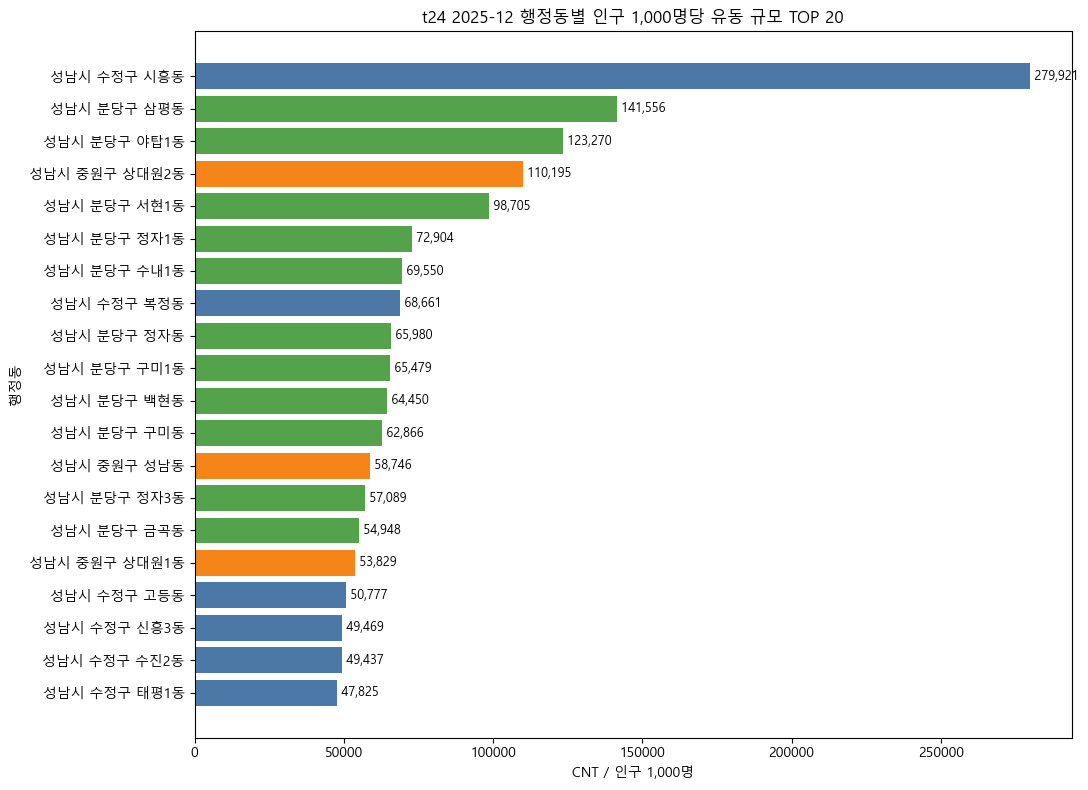

In [113]:
fig, ax = plt.subplots(figsize=(11, 8))
colors = {"성남시 수정구": "#4C78A8", "성남시 중원구": "#F58518", "성남시 분당구": "#54A24B"}
bar_colors = viz_top20["CTY_NM"].map(colors).fillna("#999999")

ax.barh(viz_top20["LABEL"][::-1], viz_top20["CNT_PER_1K_POP"][::-1], color=bar_colors[::-1])
ax.set_title(f"{focus_table_id} {viz_latest_month:%Y-%m} 행정동별 인구 1,000명당 유동 규모 TOP 20")
ax.set_xlabel("CNT / 인구 1,000명")
ax.set_ylabel("행정동")

for i, value in enumerate(viz_top20["CNT_PER_1K_POP"][::-1]):
    ax.text(value, i, f" {value:,.0f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()


**그래프 설명 - 최근 월 TOP 20 막대그래프**

최근 월에 인구 대비 유동 규모가 큰 행정동을 순위로 보여줍니다. 색은 구를 구분합니다. 같은 구의 행정동이 상위권에 몰리면 구 단위 특성이 강한 것이고, 여러 구에 흩어져 있으면 특정 행정동의 개별 특성이 강한 것으로 볼 수 있습니다.


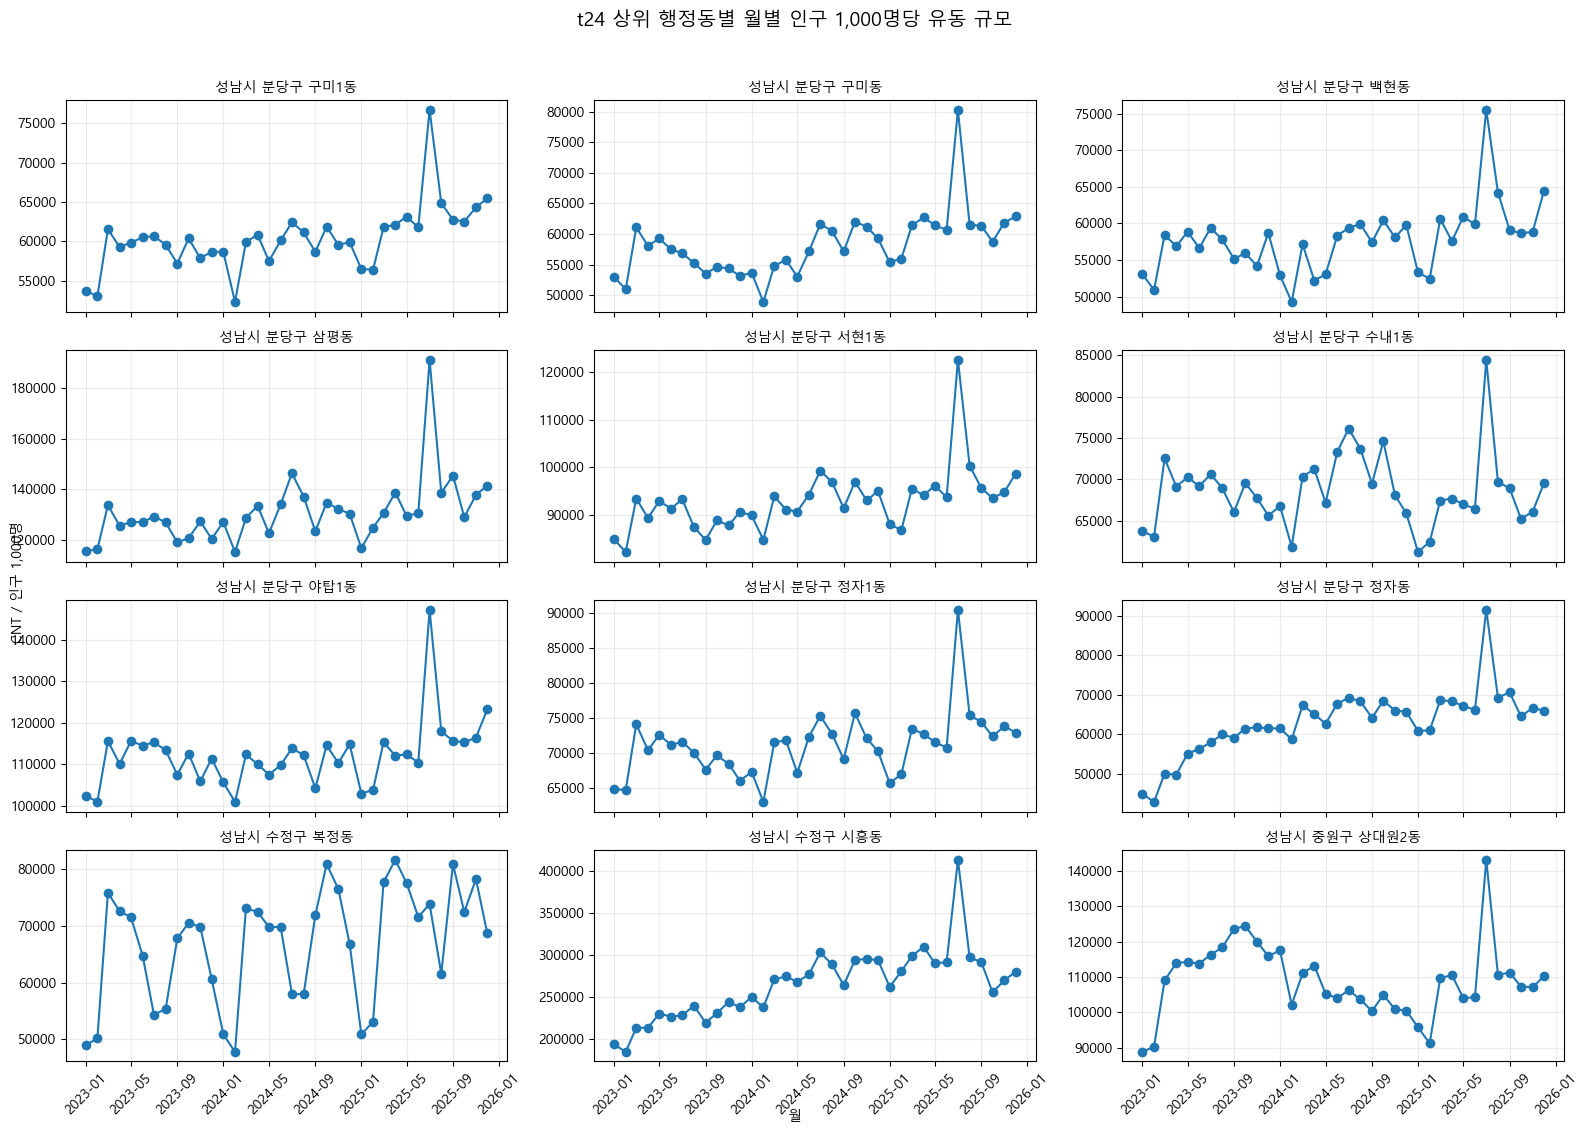

In [114]:
top12_codes = viz_top20["ADMI_CD"].head(12).tolist()
top12_trend = viz_df[viz_df["ADMI_CD"].isin(top12_codes)].copy()
top12_trend["LABEL"] = top12_trend["CTY_NM"] + " " + top12_trend["ADMI_NM"]

fig, axes = plt.subplots(4, 3, figsize=(16, 11), sharex=True)
axes = axes.ravel()

for ax, (label, sub) in zip(axes, top12_trend.groupby("LABEL")):
    sub = sub.sort_values("BASE_MONTH")
    ax.plot(sub["BASE_MONTH"], sub["CNT_PER_1K_POP"], marker="o", linewidth=1.5)
    ax.set_title(label, fontsize=10)
    ax.grid(alpha=0.25)
    ax.tick_params(axis="x", rotation=45)

for ax in axes[len(top12_trend["LABEL"].unique()):]:
    ax.axis("off")

fig.suptitle(f"{focus_table_id} 상위 행정동별 월별 인구 1,000명당 유동 규모", y=1.02, fontsize=14)
fig.text(0.5, 0.01, "월", ha="center")
fig.text(0.01, 0.5, "CNT / 인구 1,000명", va="center", rotation="vertical")
plt.tight_layout()
plt.show()


**그래프 설명 - 상위 행정동 소형 추세 그래프**

상위 행정동 12개를 각각 작은 선 그래프로 나눠 봅니다. 모든 행정동을 한 그래프에 겹치면 복잡해지므로, 행정동별로 상승·하락·반복 패턴을 따로 확인하기 위한 그래프입니다.


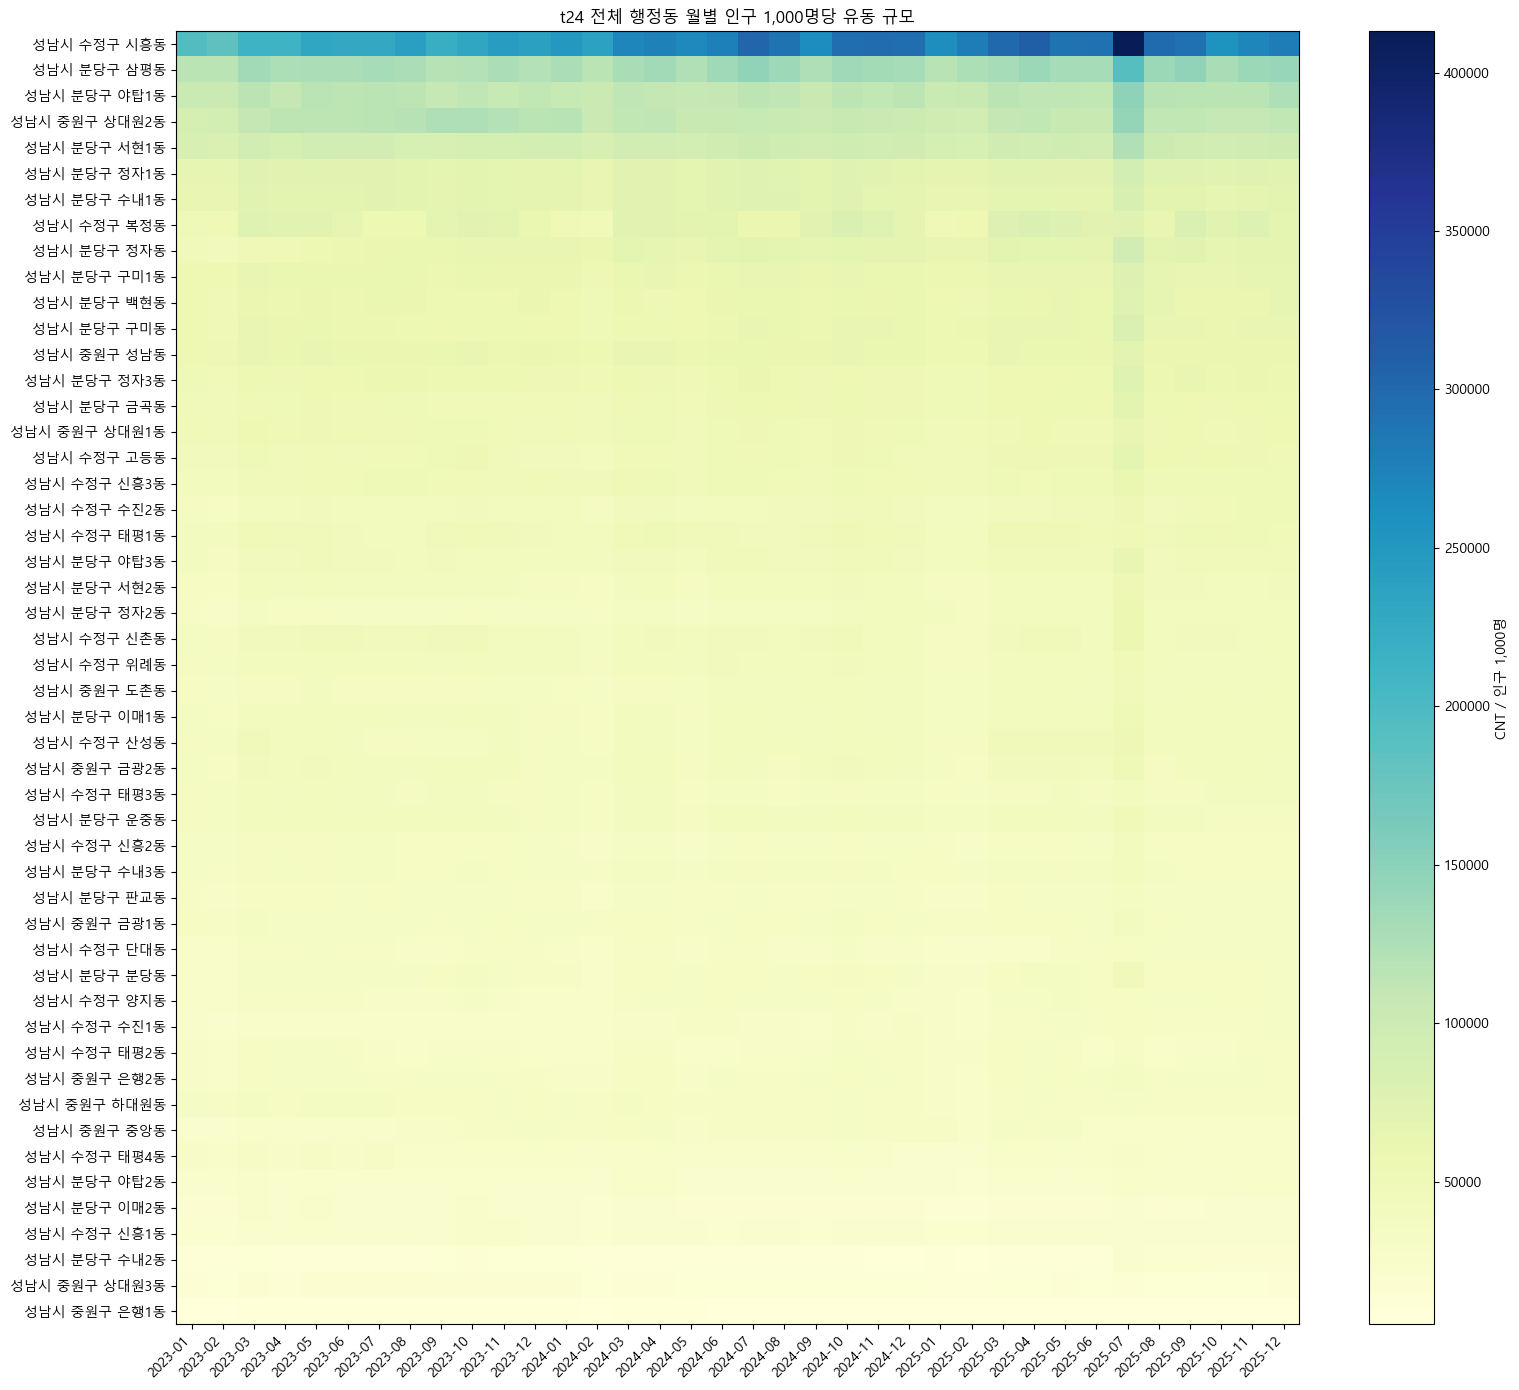

In [115]:
heatmap_all = viz_df.copy()
heatmap_all["LABEL"] = heatmap_all["CTY_NM"] + " " + heatmap_all["ADMI_NM"]

latest_order = (
    heatmap_all[heatmap_all["BASE_MONTH"] == viz_latest_month]
    .sort_values("CNT_PER_1K_POP", ascending=False)["LABEL"]
    .tolist()
)

heatmap_all_pivot = heatmap_all.pivot(index="LABEL", columns="YEAR_MONTH", values="CNT_PER_1K_POP")
heatmap_all_pivot = heatmap_all_pivot.loc[[x for x in latest_order if x in heatmap_all_pivot.index]]

fig_height = max(10, len(heatmap_all_pivot) * 0.28)
fig, ax = plt.subplots(figsize=(16, fig_height))
im = ax.imshow(heatmap_all_pivot.values, aspect="auto", cmap="YlGnBu")
ax.set_xticks(range(len(heatmap_all_pivot.columns)))
ax.set_xticklabels(heatmap_all_pivot.columns, rotation=45, ha="right")
ax.set_yticks(range(len(heatmap_all_pivot.index)))
ax.set_yticklabels(heatmap_all_pivot.index)
ax.set_title(f"{focus_table_id} 전체 행정동 월별 인구 1,000명당 유동 규모")
fig.colorbar(im, ax=ax, label="CNT / 인구 1,000명")
plt.tight_layout()
plt.show()


**그래프 설명 - 전체 행정동 월별 히트맵**

전체 행정동을 최근 월 인구 보정 유동 규모 순서로 정렬한 히트맵입니다. 가로로 진한 구간이 이어지면 해당 행정동의 지속적 강세, 세로로 여러 행정동이 동시에 진해지면 특정 월의 공통 상승 요인을 의심할 수 있습니다.


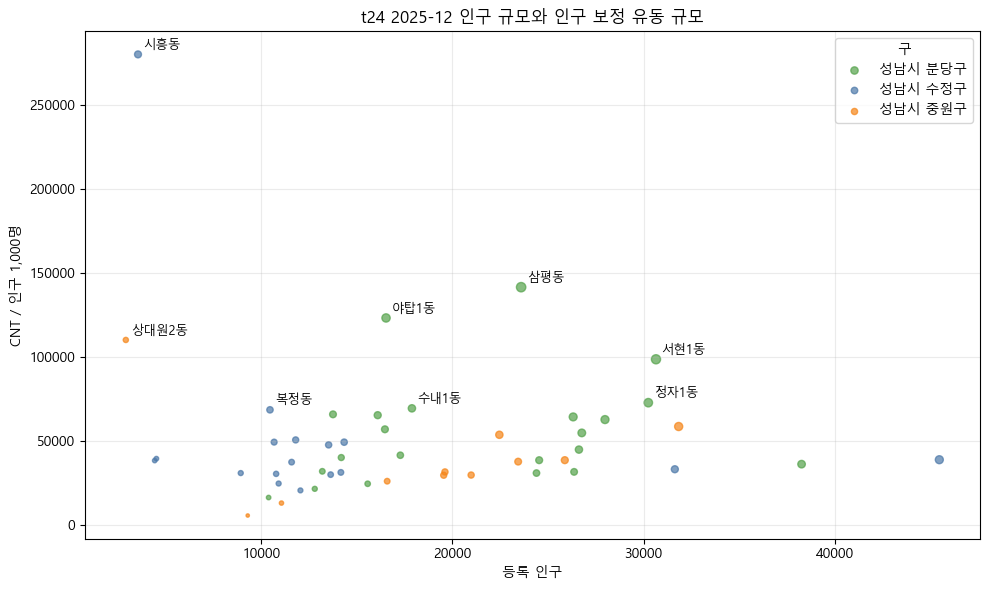

In [116]:
fig, ax = plt.subplots(figsize=(10, 6))

for cty_name, sub in viz_latest.groupby("CTY_NM"):
    ax.scatter(
        sub["TOTAL_POP"],
        sub["CNT_PER_1K_POP"],
        s=np.sqrt(sub["CNT_SUM"]) / 40,
        alpha=0.7,
        label=cty_name,
        color=colors.get(cty_name, None),
    )

label_df = viz_latest.sort_values("CNT_PER_1K_POP", ascending=False).head(8)
for _, row in label_df.iterrows():
    ax.annotate(row["ADMI_NM"], (row["TOTAL_POP"], row["CNT_PER_1K_POP"]), fontsize=9, xytext=(4, 4), textcoords="offset points")

ax.set_title(f"{focus_table_id} {viz_latest_month:%Y-%m} 인구 규모와 인구 보정 유동 규모")
ax.set_xlabel("등록 인구")
ax.set_ylabel("CNT / 인구 1,000명")
ax.legend(title="구")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


**그래프 설명 - 인구 규모 vs 인구 보정 유동 규모 산점도**

x축은 등록 인구, y축은 인구 1,000명당 유동 규모입니다. 오른쪽 위는 인구도 많고 유동도 큰 지역, 왼쪽 위는 거주 인구는 작지만 외부 유입이나 활동성이 큰 지역 후보입니다. 점 크기는 `CNT_SUM` 규모를 반영합니다.


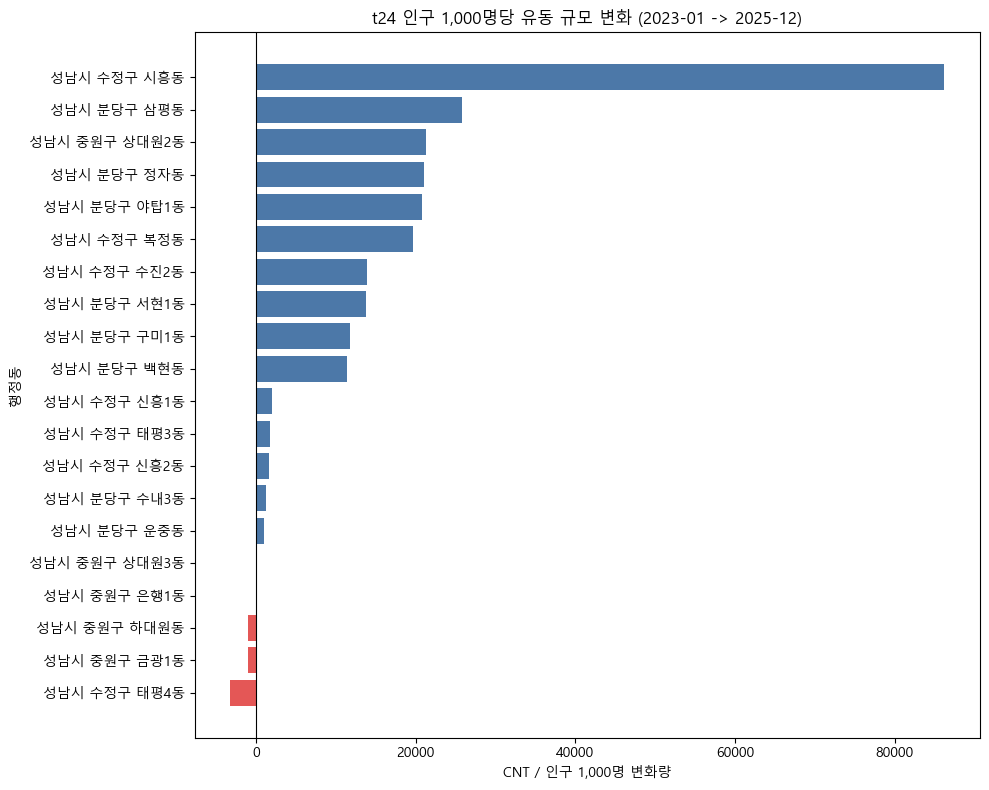

In [117]:
rank_first_month = viz_df["BASE_MONTH"].min()
rank_latest_month = viz_df["BASE_MONTH"].max()

rank_first = (
    viz_df[viz_df["BASE_MONTH"] == rank_first_month]
    [["ADMI_CD", "CTY_NM", "ADMI_NM", "CNT_PER_1K_POP"]]
    .rename(columns={"CNT_PER_1K_POP": "FIRST_CNT_PER_1K_POP"})
)
rank_latest = (
    viz_df[viz_df["BASE_MONTH"] == rank_latest_month]
    [["ADMI_CD", "CNT_PER_1K_POP"]]
    .rename(columns={"CNT_PER_1K_POP": "LATEST_CNT_PER_1K_POP"})
)

rank_change = rank_first.merge(rank_latest, on="ADMI_CD", how="inner")
rank_change["CHANGE"] = rank_change["LATEST_CNT_PER_1K_POP"] - rank_change["FIRST_CNT_PER_1K_POP"]
rank_change["LABEL"] = rank_change["CTY_NM"] + " " + rank_change["ADMI_NM"]

rank_change_plot = pd.concat([
    rank_change.nlargest(10, "CHANGE").assign(TYPE="증가 TOP 10"),
    rank_change.nsmallest(10, "CHANGE").assign(TYPE="감소 TOP 10"),
]).sort_values("CHANGE")

fig, ax = plt.subplots(figsize=(10, 8))
bar_colors = np.where(rank_change_plot["CHANGE"] >= 0, "#4C78A8", "#E45756")
ax.barh(rank_change_plot["LABEL"], rank_change_plot["CHANGE"], color=bar_colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title(f"{focus_table_id} 인구 1,000명당 유동 규모 변화 ({rank_first_month:%Y-%m} -> {rank_latest_month:%Y-%m})")
ax.set_xlabel("CNT / 인구 1,000명 변화량")
ax.set_ylabel("행정동")
plt.tight_layout()
plt.show()


**그래프 설명 - 기간 전체 증가/감소 행정동**

첫 월과 최근 월의 인구 보정 유동 규모 차이를 보여줍니다. 파란색은 증가, 빨간색은 감소입니다. 단기 급변이 아니라 분석 기간 전체에서 구조적으로 커졌거나 작아진 행정동을 찾는 데 사용합니다.


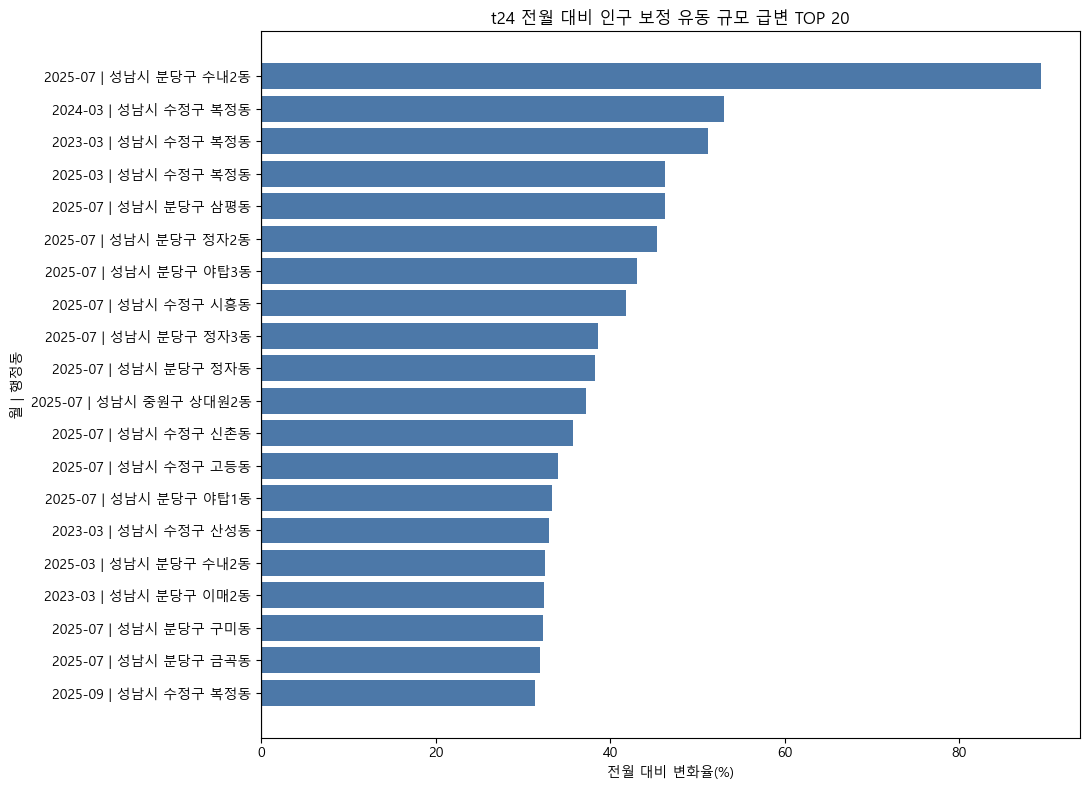

In [118]:
outlier_plot = monthly_admin_outliers.head(20).copy()
outlier_plot["LABEL"] = outlier_plot["YEAR_MONTH"] + " | " + outlier_plot["CTY_NM"] + " " + outlier_plot["ADMI_NM"]

fig, ax = plt.subplots(figsize=(11, 8))
bar_colors = np.where(outlier_plot["CNT_PER_PERSON_MOM_PCT"] >= 0, "#4C78A8", "#E45756")
ax.barh(outlier_plot["LABEL"][::-1], (outlier_plot["CNT_PER_PERSON_MOM_PCT"] * 100)[::-1], color=bar_colors[::-1])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title(f"{focus_table_id} 전월 대비 인구 보정 유동 규모 급변 TOP 20")
ax.set_xlabel("전월 대비 변화율(%)")
ax.set_ylabel("월 | 행정동")
plt.tight_layout()
plt.show()


**그래프 설명 - 전월 대비 급증/급감 TOP 20**

전월 대비 변화율이 큰 행정동·월을 보여줍니다. 양수는 급증, 음수는 급감입니다. 이 그래프는 원인 분석 후보를 좁히는 용도이며, 실제 해석은 해당 월의 행사, 명절, 개학/방학, 데이터 결측 가능성을 함께 확인해야 합니다.


## t24 목적·시간대 세부 시각화

아래 두 그래프는 기본 예시인 `t24`를 더 자세히 보기 위한 세부 시각화입니다. 월별 행정동 기준은 유지하되, 목적 코드와 시간대까지 나눠서 어떤 성격의 유동이 상위 행정동을 만들었는지 확인합니다. 이 셀들은 `t24` 원본 parquet를 다시 집계하므로 실행 시간이 걸릴 수 있습니다.


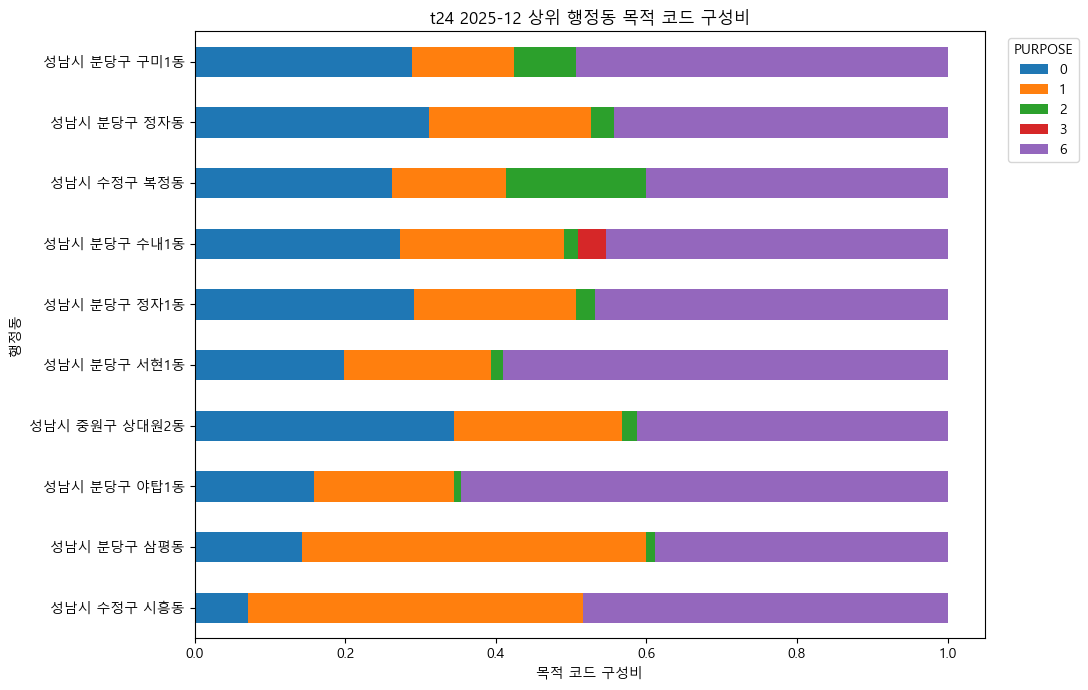

In [119]:
t24_latest_month = viz_latest_month
t24_latest_month_str = t24_latest_month.strftime("%Y-%m")
t24_top10_codes = viz_top20["ADMI_CD"].head(10).tolist()
t24_top10_codes_sql = ", ".join(map(str, t24_top10_codes))
latest_population_for_viz = population_clean[population_clean["BASE_MONTH"] == t24_latest_month][["ADMI_CD", "CTY_NM", "ADMI_NM"]]

t24_latest_purpose = q(f'''
    SELECT
        ADMI_CD,
        PURPOSE,
        SUM(CNT) AS CNT_SUM
    FROM {scan_sql("t24")}
    WHERE date_trunc('month', CAST(ETL_YMD AS DATE)) = DATE '{t24_latest_month:%Y-%m-01}'
      AND ADMI_CD IN ({t24_top10_codes_sql})
    GROUP BY 1, 2
''')

t24_latest_purpose = t24_latest_purpose.merge(
    latest_population_for_viz,
    on="ADMI_CD",
    how="left",
)
t24_latest_purpose["LABEL"] = t24_latest_purpose["CTY_NM"] + " " + t24_latest_purpose["ADMI_NM"]
t24_latest_purpose["PURPOSE"] = t24_latest_purpose["PURPOSE"].astype(str)
t24_latest_purpose["PURPOSE_SHARE"] = t24_latest_purpose["CNT_SUM"] / t24_latest_purpose.groupby("ADMI_CD")["CNT_SUM"].transform("sum")

purpose_stack = t24_latest_purpose.pivot(index="LABEL", columns="PURPOSE", values="PURPOSE_SHARE").fillna(0)
purpose_stack = purpose_stack.loc[viz_top20.head(10)["LABEL"]]

ax = purpose_stack.plot(kind="barh", stacked=True, figsize=(11, 7), title=f"t24 {t24_latest_month_str} 상위 행정동 목적 코드 구성비")
ax.set_xlabel("목적 코드 구성비")
ax.set_ylabel("행정동")
ax.legend(title="PURPOSE", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


**그래프 설명 - 상위 행정동 목적 코드 구성비**

최근 월 인구 보정 유동 규모 상위 10개 행정동의 목적 코드 비중입니다. 상위 행정동이라도 목적 구성이 다르면 지역 성격이 다를 수 있습니다. 예를 들어 특정 목적 코드가 한 행정동에서 압도적으로 높다면 해당 지역의 방문 목적이 뚜렷하다고 볼 수 있습니다.


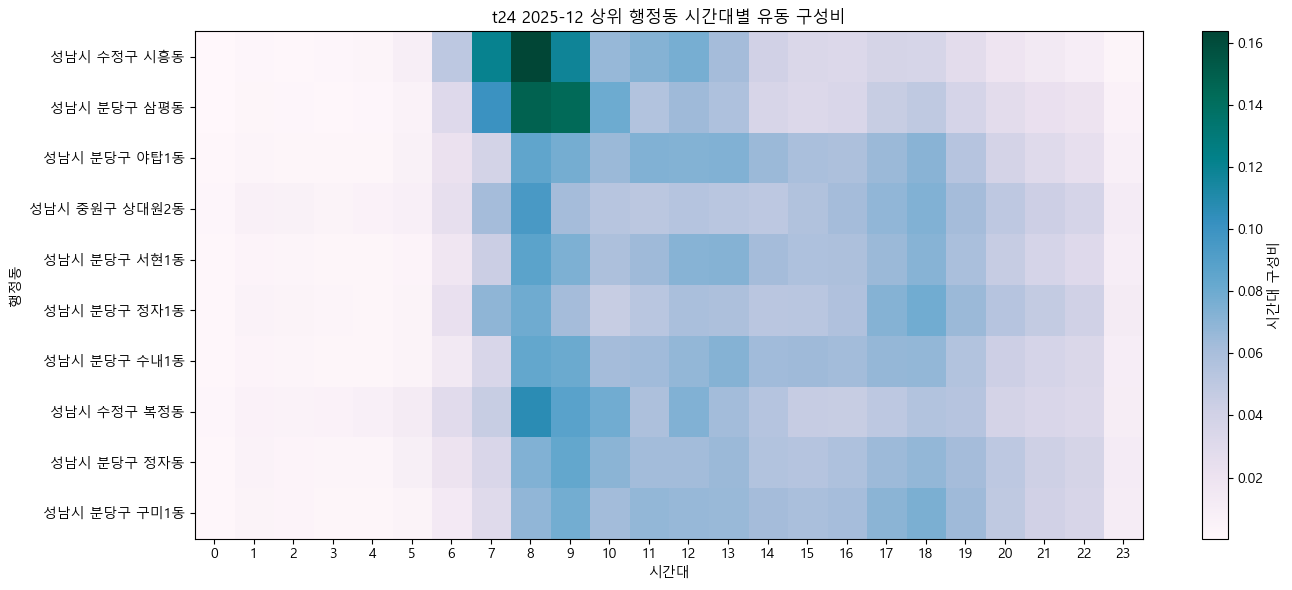

In [120]:
t24_latest_hour = q(f'''
    SELECT
        ADMI_CD,
        CAST(TIME_CD AS INTEGER) AS HOUR,
        SUM(CNT) AS CNT_SUM
    FROM {scan_sql("t24")}
    WHERE date_trunc('month', CAST(ETL_YMD AS DATE)) = DATE '{t24_latest_month:%Y-%m-01}'
      AND ADMI_CD IN ({t24_top10_codes_sql})
    GROUP BY 1, 2
''')

t24_latest_hour = t24_latest_hour.merge(
    latest_population_for_viz,
    on="ADMI_CD",
    how="left",
)
t24_latest_hour["LABEL"] = t24_latest_hour["CTY_NM"] + " " + t24_latest_hour["ADMI_NM"]
t24_latest_hour["HOUR_SHARE"] = t24_latest_hour["CNT_SUM"] / t24_latest_hour.groupby("ADMI_CD")["CNT_SUM"].transform("sum")

hour_pivot = t24_latest_hour.pivot(index="LABEL", columns="HOUR", values="HOUR_SHARE").fillna(0)
hour_pivot = hour_pivot.loc[viz_top20.head(10)["LABEL"]]

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(hour_pivot.values, aspect="auto", cmap="PuBuGn")
ax.set_xticks(range(len(hour_pivot.columns)))
ax.set_xticklabels(hour_pivot.columns)
ax.set_yticks(range(len(hour_pivot.index)))
ax.set_yticklabels(hour_pivot.index)
ax.set_title(f"t24 {t24_latest_month_str} 상위 행정동 시간대별 유동 구성비")
ax.set_xlabel("시간대")
ax.set_ylabel("행정동")
fig.colorbar(im, ax=ax, label="시간대 구성비")
plt.tight_layout()
plt.show()


**그래프 설명 - 상위 행정동 시간대별 유동 구성비**

최근 월 상위 행정동 10개의 시간대별 유동 구성비 히트맵입니다. 특정 행정동이 오전·점심·저녁 중 어느 시간대에 강한지 확인할 수 있습니다. 목적 코드 구성비와 함께 보면 업무지, 상업지, 주거지 성격을 더 잘 구분할 수 있습니다.


## 9. 젠트리피케이션 예측용 변수별 해석 메모

아래 내용은 각 변수를 예측 분석에 쓸지 판단하기 위한 정리이다. 현재 데이터에는 임대료, 지가, 공실률, 폐업률처럼 젠트리피케이션을 직접 측정하는 변수가 없으므로, 아래 변수들은 **젠트리피케이션 자체가 아니라 외부 수요 증가, 상권 활성화, 거주 구조 변화의 proxy**로 해석한다.

### `external_inflow` (성남시 외부에서 해당 행정동으로 들어온 이동량)

- 왜 이렇게 나올 수 있는가: 업무지구, 상업시설, 교통 접근성이 좋은 행정동은 성남시 외부에서 들어오는 이동량이 커질 수 있다. 분당구나 판교·서현·야탑처럼 외부 방문 목적이 뚜렷한 지역에서 높게 나타날 가능성이 있다.
- 젠트리피케이션과의 연결: 외부 방문객 증가는 외부 소비 수요가 지역 안으로 들어온다는 뜻이다. 이는 상권 활성화, 임대료 상승 압력, 업종 변화와 연결될 수 있어 젠트리피케이션 압력을 설명하는 핵심 변수로 볼 수 있다.
- 사용 판단: **사용 권장**. 다만 행정동 규모 차이가 있으므로 `external_inflow_per_1k_pop`처럼 인구 보정 지표도 같이 만드는 것이 좋다.

### `external_inflow_change_rate` (외부유입의 전월 대비 변화율)

- 왜 이렇게 나올 수 있는가: 신규 시설, 행사, 계절성, 교통 변화, 전월 값이 작은 지역의 기저효과 때문에 크게 튈 수 있다.
- 젠트리피케이션과의 연결: 외부유입의 빠른 증가는 외부 수요가 특정 지역으로 몰리고 있다는 신호다. 젠트리피케이션은 한 시점의 규모보다 지속적인 변화 방향이 중요하므로 변화율은 의미가 있다.
- 사용 판단: **조건부 사용**. 월별 변화율은 노이즈가 크므로 3개월 이동평균이나 전년동월 대비 변화율로 바꾸는 것이 안전하다.

### `floating_pop` (행정동별 전체 유동인구 규모)

- 왜 이렇게 나올 수 있는가: 인구가 많거나 직장·상업·교통 기능이 집중된 지역은 자연스럽게 유동인구가 크게 나온다.
- 젠트리피케이션과의 연결: 유동인구 증가는 지역 활동량과 소비 가능성이 커졌다는 신호다. 상권이 활성화되는 지역은 임대료 상승 압력과 기존 상권 변화 가능성이 커질 수 있다.
- 사용 판단: **보조 변수로 사용**. 원값은 지역 규모 영향을 많이 받으므로 단독 사용보다 인구 대비 지표로 변환하는 것이 좋다.

### `floating_change_rate` (전체 유동인구의 전월 대비 변화율)

- 왜 이렇게 나올 수 있는가: 날씨, 계절, 명절, 방학, 행사, 월별 주말 수 차이 같은 단기 요인에 영향을 받을 수 있다.
- 젠트리피케이션과의 연결: 유동인구가 지속적으로 증가하면 지역이 거주 중심보다 방문·소비 중심으로 바뀌는 흐름을 의심할 수 있다.
- 사용 판단: **조건부 사용**. 한 달 변화율보다 3개월 이동평균 증가율로 쓰는 편이 좋다.

### `floating_pop_per_1k_pop` (등록 인구 1,000명당 유동인구)

- 왜 이렇게 나올 수 있는가: 거주 인구는 적지만 방문자가 많은 상업·업무 지역에서 높게 나타난다. 순수 주거지는 총인구가 많아도 이 값이 낮을 수 있다.
- 젠트리피케이션과의 연결: 거주 인구 대비 유동 규모가 커지는 것은 지역이 주민 생활권보다 외부 방문·소비 중심 공간으로 바뀌고 있다는 신호다.
- 사용 판단: **강력 추천**. `floating_pop` 원값보다 예측 변수로 더 적합하다.

### `working_pop` (경제활동 연령층 유동인구 proxy)

- 왜 이렇게 나올 수 있는가: 업무지구, 상업지, 교통 중심지는 경제활동 연령층의 이동이 많다. 다만 전체 유동인구가 큰 지역에서는 자연스럽게 같이 커질 수 있다.
- 젠트리피케이션과의 연결: 경제활동 연령층은 소비·근로·여가 활동과 연결되므로 신규 소비층 증가를 설명하는 proxy가 될 수 있다.
- 사용 판단: **원값은 주의**. `floating_pop`과 중복성이 높으면 모델에서 제외하고 `working_pop_share`를 쓰는 편이 낫다.

### `working_pop_change_rate` (경제활동 연령층 유동인구의 전월 대비 변화율)

- 왜 이렇게 나올 수 있는가: 전체 유동인구 변화와 같은 방향으로 움직일 가능성이 크다.
- 젠트리피케이션과의 연결: 소비 가능 연령층의 유입 증가를 볼 수 있지만, 전체 유동인구 증가와 구분되지 않으면 해석력이 약하다.
- 사용 판단: **보조 변수**. `floating_change_rate`와 상관이 높으면 버리거나 `working_pop_share_change`로 바꾼다.

### `working_pop_share` (전체 유동인구 중 경제활동 연령층 비중)

- 왜 이렇게 나올 수 있는가: 상업·업무 중심지는 전체 유동인구 중 경제활동 연령층 비중이 높게 나타날 수 있다.
- 젠트리피케이션과의 연결: 단순히 사람이 많은지가 아니라 어떤 연령층이 늘어나는지를 보여준다. 소비력 있는 활동 인구 비중 증가는 상권 고급화나 업종 변화와 연결해 해석할 수 있다.
- 사용 판단: **사용 권장**. `working_pop` 원값보다 모델에 넣기 좋다.

### `TOTAL_POP` (행정동별 등록 총인구)

- 왜 이렇게 나올 수 있는가: 신축 입주, 재개발, 전출입, 고령화 등에 따라 달라진다.
- 젠트리피케이션과의 연결: 유동인구와 외부유입은 증가하는데 등록 인구가 정체되거나 감소하면, 지역이 거주 공간보다 소비·방문 공간으로 바뀌고 있을 가능성을 설명할 수 있다.
- 사용 판단: **보정 변수로 사용**. 단독 핵심 변수보다는 `per_1k_pop` 계산에 필요하다.

### `population_growth_rate` (등록 총인구 증가율)

- 왜 이렇게 나올 수 있는가: 주택 공급, 이주, 재개발, 지역 선호 변화가 반영될 수 있다.
- 젠트리피케이션과의 연결: 외부유입은 증가하지만 인구 증가율이 낮거나 음수이면 기존 거주 안정성이 약해지는 지역으로 해석할 여지가 있다.
- 사용 판단: **보조 변수로 사용**. 월별보다 6개월 또는 1년 변화율이 더 안정적이다.

### `HOUSEHOLDS` (행정동별 세대수)

- 왜 이렇게 나올 수 있는가: 1인 가구 증가, 소형 주택·오피스텔 증가, 가족 단위 가구 분화로 세대수가 증가할 수 있다.
- 젠트리피케이션과의 연결: 총인구가 크게 늘지 않는데 세대수만 늘면 가족 단위 거주보다 소형 가구 중심으로 주거 구조가 바뀌는 신호일 수 있다.
- 사용 판단: **사용 가능**. 반드시 `TOTAL_POP`, `HOUSEHOLD_SIZE`와 같이 봐야 한다.

### `household_growth_rate` (세대수 증가율)

- 왜 이렇게 나올 수 있는가: 소형 가구 증가나 신규 소형 주택 공급의 영향이 반영될 수 있다.
- 젠트리피케이션과의 연결: 세대수 증가와 세대당 인구 감소가 동시에 나타나면 신규 소형 가구 유입 또는 기존 가족형 주거 구조 약화를 의심할 수 있다.
- 사용 판단: **조건부 사용**. 총인구 증가율과 함께 비교해야 의미가 생긴다.

### `HOUSEHOLD_SIZE` (세대당 평균 인구)

- 왜 이렇게 나올 수 있는가: 1인 가구, 청년층, 고령층 단독가구 증가 또는 가족 단위 가구 감소에 따라 낮아질 수 있다.
- 젠트리피케이션과의 연결: 세대당 인구 감소는 지역의 거주 구조 변화 가능성을 보여준다. 외부유입 증가와 함께 나타나면 주거지 성격 변화 해석에 도움이 된다.
- 사용 판단: **사용 권장**. 단, 고령화 영향과 구분이 어려우므로 유동인구 변수와 같이 해석한다.

### `household_size_change_rate` (세대당 인구 변화율)

- 왜 이렇게 나올 수 있는가: 단기간에는 변화가 작지만 특정 지역에서 지속적으로 감소하면 주거 구조 변화가 진행 중일 수 있다.
- 젠트리피케이션과의 연결: 외부유입과 유동인구가 증가하는 동시에 세대당 인구가 감소하면, 지역이 가족형 주거지에서 소형 가구·방문 중심 구조로 바뀌는 흐름을 설명할 수 있다.
- 사용 판단: **보조 핵심 변수**. 변화폭이 작으면 장기 변화율로 쓰는 것이 낫다.

### `DURATION` (지역 내 체류시간)

- 왜 이렇게 나올 수 있는가: 업무, 쇼핑, 여가, 병원 방문 등 실제 목적 활동이 있는 지역에서 길게 나타날 수 있다. 단순 통과 지역은 짧을 가능성이 높다.
- 젠트리피케이션과의 연결: 체류시간 증가는 사람들이 그 지역에서 소비·업무·여가 활동을 하고 있다는 신호다. 외부유입 증가와 함께 나타나면 상권 활성화 가능성이 더 강해진다.
- 사용 판단: **사용 권장**. 평균보다 `long_stay_share`로 바꾸면 해석력이 더 좋아진다.

### `long_stay_share` (일정 시간 이상 장기 체류 비중)

- 왜 이렇게 나올 수 있는가: 상업시설, 업무시설, 여가 공간이 많은 지역은 긴 체류 비중이 높아질 수 있다.
- 젠트리피케이션과의 연결: 단순 방문이 아니라 지역 안에서 머무는 시간이 늘어나는 것이므로 상권 활성화 proxy로 적합하다.
- 사용 판단: **강력 추천**. 120분 이상 또는 180분 이상처럼 기준을 고정해서 만든다.

### `PURPOSE` (이동 목적 코드)

- 왜 이렇게 나올 수 있는가: 이동 목적 코드이지만 현재 코드 정의가 명확하지 않다.
- 젠트리피케이션과의 연결: 목적 코드 정의가 확보되면 쇼핑·여가·업무 목적 이동을 상권 변화와 연결할 수 있다. 하지만 정의가 없으면 해석이 불안정하다.
- 사용 판단: **현재는 메인 변수 제외 권장**. 코드 정의 확인 후 보조 변수로 다시 검토한다.

### `TRANS_GB` (이동수단 또는 이동 유형 코드)

- 왜 이렇게 나올 수 있는가: 이동수단 또는 이동 유형 코드로 보이지만 현재 정의가 명확하지 않다.
- 젠트리피케이션과의 연결: 교통 접근성과 외부 방문 가능성을 설명할 수 있지만, 코드 정의 없이는 어떤 이동수단 증가인지 말하기 어렵다.
- 사용 판단: **현재는 제외 또는 보조 분석만 권장**. 코드 정의가 확인되면 교통 접근성 proxy로 활용 가능하다.

## 예측 변수 후보 선택 기준

| 우선순위 | 변수 | 변수 설명 | 판단 |
|---|---|---|---|
| 1 | `floating_pop_per_1k_pop` | 등록 인구 1,000명당 유동인구 | 지역 규모 보정이 가능하므로 사용 권장 |
| 2 | `external_inflow_per_1k_pop` | 등록 인구 1,000명당 외부유입 이동량 | 외부 수요를 직접 보여주므로 사용 권장 |
| 3 | `external_inflow_change_rate_3m` | 외부유입 변화율의 3개월 이동평균 | 이동평균 처리 후 사용 |
| 4 | `working_pop_share` | 전체 유동인구 중 경제활동 연령층 비중 | 소비 가능 연령층 비율로 사용 권장 |
| 5 | `HOUSEHOLD_SIZE`, `household_size_change_rate` | 세대당 평균 인구와 그 변화율 | 주거 구조 변화 보조 지표로 사용 |
| 6 | `long_stay_share` | 일정 시간 이상 장기 체류한 비중 | 체류 기반 상권 활성화 지표로 사용 |
| 7 | `floating_pop`, `working_pop` 원값 | 전체 유동인구와 경제활동 연령층 유동인구 원규모 | 중복 가능성이 높아 보조로만 사용 |
| 8 | `PURPOSE`, `TRANS_GB` | 이동 목적 코드와 이동수단/이동유형 코드 | 코드 정의 확인 전까지 메인 변수 제외 |

최종 모델링 후보는 `external_inflow_per_1k_pop`, `external_inflow_change_rate_3m`, `floating_pop_per_1k_pop`, `floating_change_rate_3m`, `working_pop_share`, `household_growth_rate`, `population_growth_rate`, `household_size_change_rate`, `long_stay_share`로 정리하는 것이 적절하다.


## EDA 결과 기반 모델링 후보 정리

아래 내용은 현재 EDA 결과를 바탕으로 한 **모델링용 통신 변수 후보안**이다.  
팀의 목표변수와 마스터 키가 정해지기 전까지는 확정된 내용이 아니라 후보안으로 관리한다.

### 1차 추천 구조

| 항목 | 후보 |
|---|---|
| 분석 단위 | 행정동-월 |
| 마스터 키 | `base_ym + admi_cd` |
| 기본 테이블 | T24 |
| 핵심 추가 테이블 | T13, T26 |
| 선택 추가 테이블 | T27 |
| 보조 참고 테이블 | T25 |

### 테이블 판단

| 테이블 | 판단 | 이유 |
|---|---|---|
| T24 | 기본 feature 후보 | 행정동 단위 유동인구라 월별 지역 feature의 뼈대로 적합 |
| T13 | 핵심 추가 후보 | 행정동 OD 이동량으로 외부유입, 유입/유출 구조 생성 가능 |
| T26 | 핵심 추가 후보 | 도착 행정동 기준 체류시간과 목적별 체류 특성 생성 가능 |
| T27 | 선택 추가 후보 | 이동수단/접근성 특성 생성 가능. T26과 중복 확인 필요 |
| T25 | 보조 참고 | 시군구 OD라 행정동 모델에서는 직접 feature보다 구 단위 압력 참고용 |
| T4~T12, T14, T16, T22, T23 | 보류/구조 파악 | 모델 단위와 직접 연결하기 전 추가 검토 필요 |

### 파생변수 후보

| 원천 | 변수 후보 | 의미 |
|---|---|---|
| T24 | `floating_pop_sum` | 월별 행정동 전체 유동량 |
| T24 | `purpose_*_ratio` | 목적별 유동 비중 |
| T24 | `daytime_cnt`, `night_cnt`, `night_ratio` | 시간대별 유동 특성 |
| T24 | `age_20_40_ratio` | 주요 소비/경제활동 연령층 비중 |
| T24 | `female_ratio`, `male_ratio` | 성별 유동 비중 |
| T13 | `inflow_cnt`, `outflow_cnt` | 유입/유출 이동량 |
| T13 | `external_inflow_cnt`, `external_inflow_ratio` | 외부유입 규모와 비중 |
| T13 | `inflow_outflow_ratio` | 유입 대비 유출 비율 |
| T26 | `avg_stay_time` | 평균 체류시간 |
| T26 | `long_stay_ratio` | 장기체류 비중 |
| T26 | `purpose_stay_avg_*` | 목적별 평균 체류시간 |
| T27 | `transport_*_ratio` | 이동수단별 비중 |
| T27 | `purpose_transport_*` | 목적+이동수단 조합 |
| T25 | `city_inflow_pressure` | 시군구 단위 유입 압력 |

주의: `PURPOSE`, `TRANS_GB`, `AGE_GRP`는 공식 정의서 확인 전까지 코드값 기준 후보 변수로만 관리한다.

In [ ]:
modeling_candidate_plan = [
    {'priority': 1, 'table': 'T24', 'role': 'base', 'feature_group': 'floating_population', 'join_key_candidate': 'base_ym + ADMI_CD'},
    {'priority': 2, 'table': 'T13', 'role': 'core_add', 'feature_group': 'inflow_outflow', 'join_key_candidate': 'base_ym + D_ADMI_CD / O_ADMI_CD'},
    {'priority': 3, 'table': 'T26', 'role': 'core_add', 'feature_group': 'stay_time', 'join_key_candidate': 'base_ym + D_ADMI_CD'},
    {'priority': 4, 'table': 'T27', 'role': 'optional_add', 'feature_group': 'transport_access', 'join_key_candidate': 'base_ym + O_ADMI_CD'},
    {'priority': 5, 'table': 'T25', 'role': 'support', 'feature_group': 'city_level_flow_pressure', 'join_key_candidate': 'base_ym + CTY_CD'},
]

pd.DataFrame(modeling_candidate_plan)